dnn_biaozhun
Metrics found: ['Residual', 'Chaos', 'Failure']
Seeds found   : [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321]
Orders found  : ['asc', 'desc']


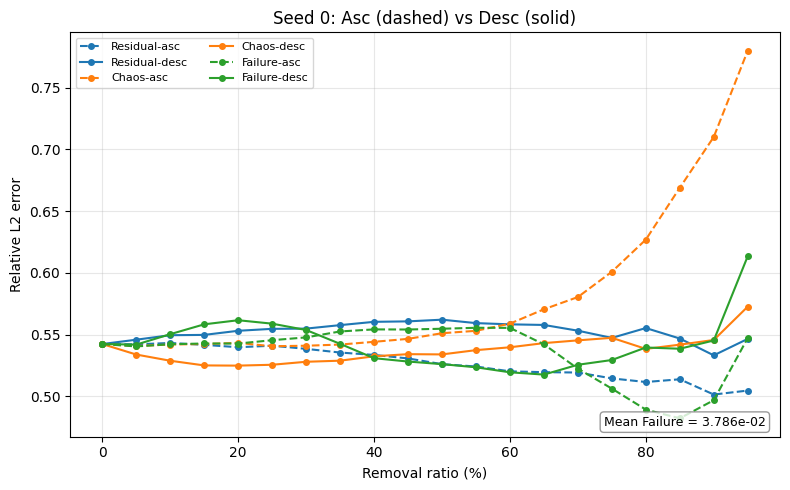

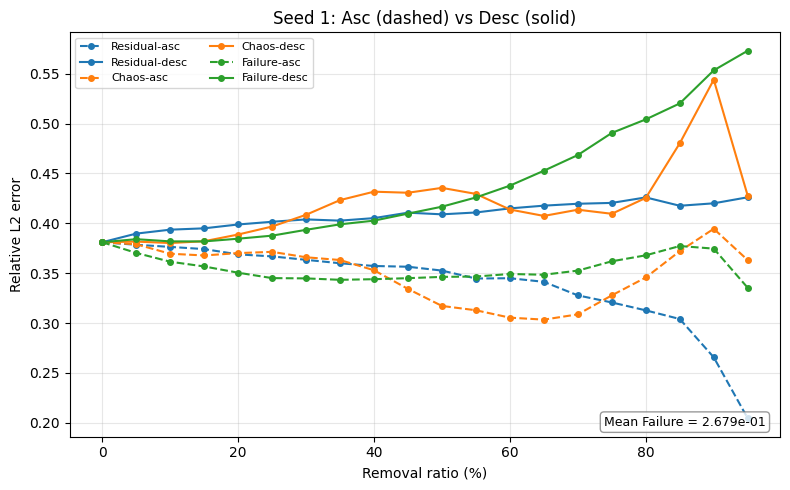

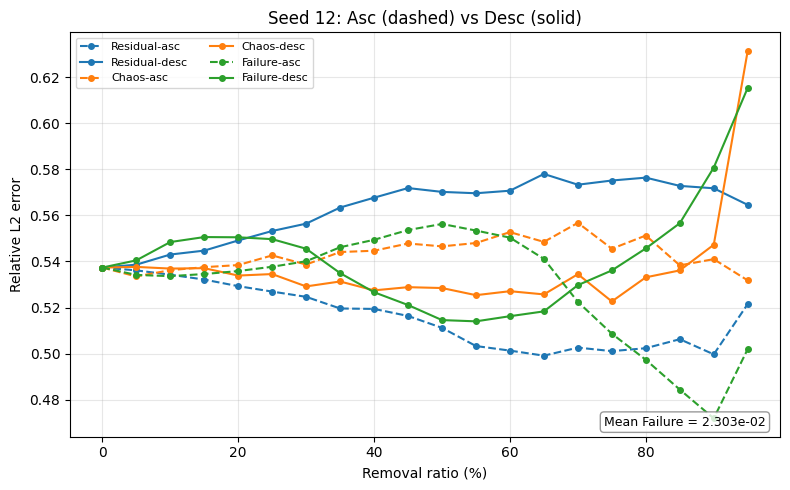

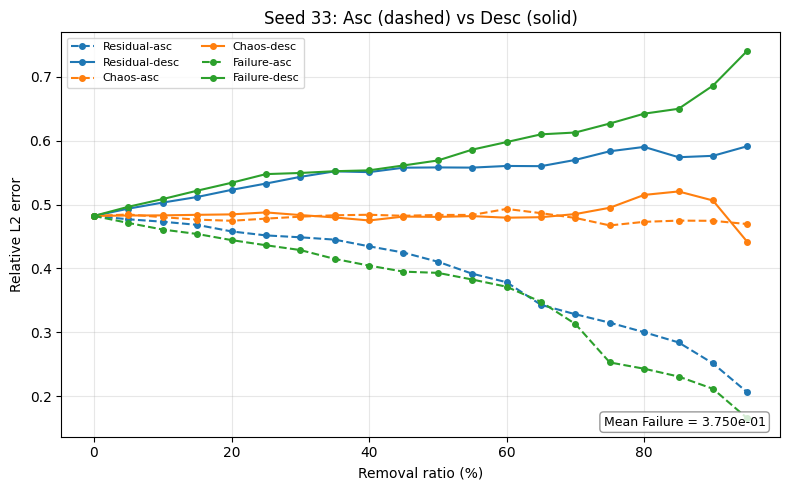

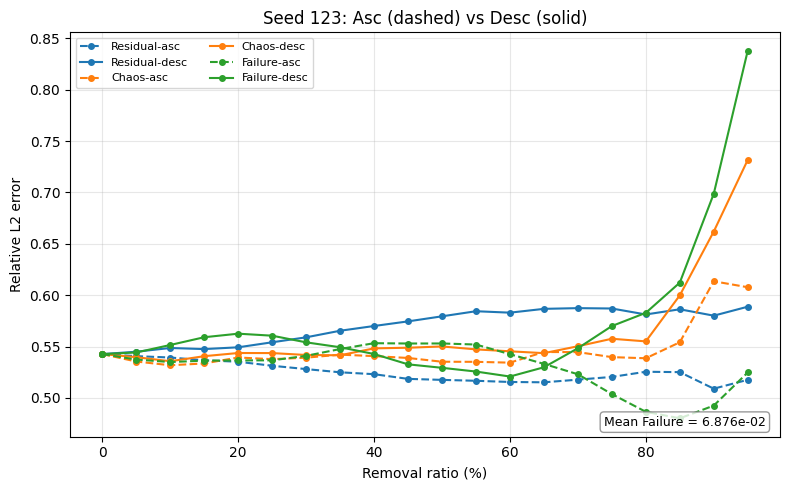

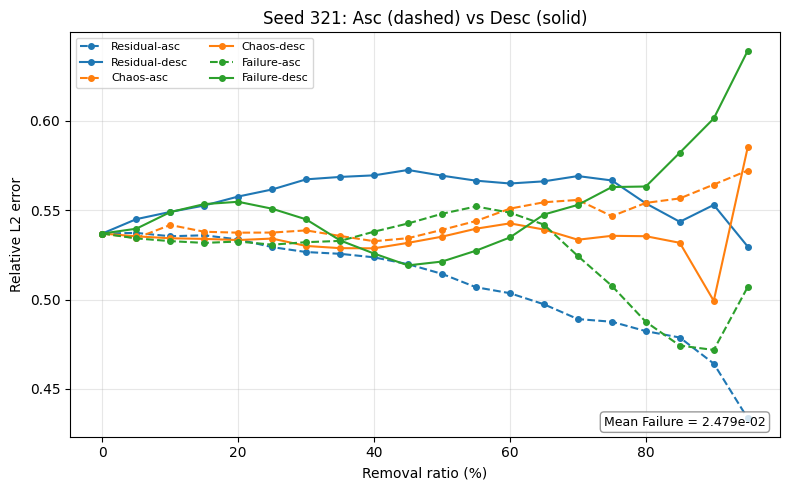

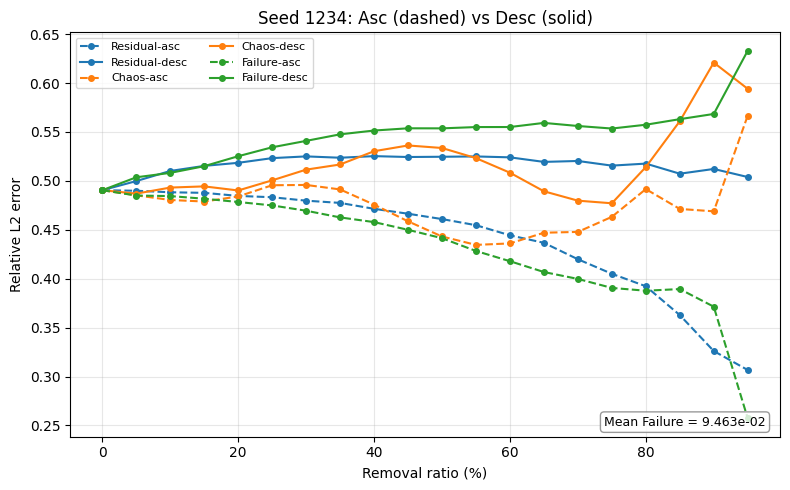

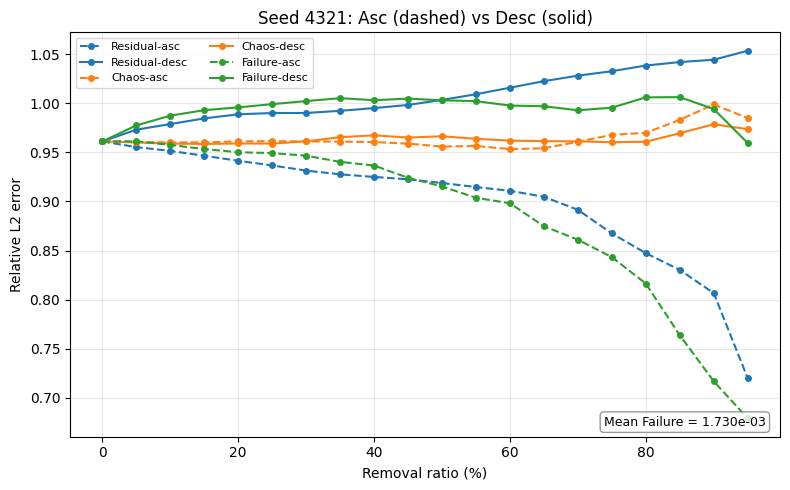

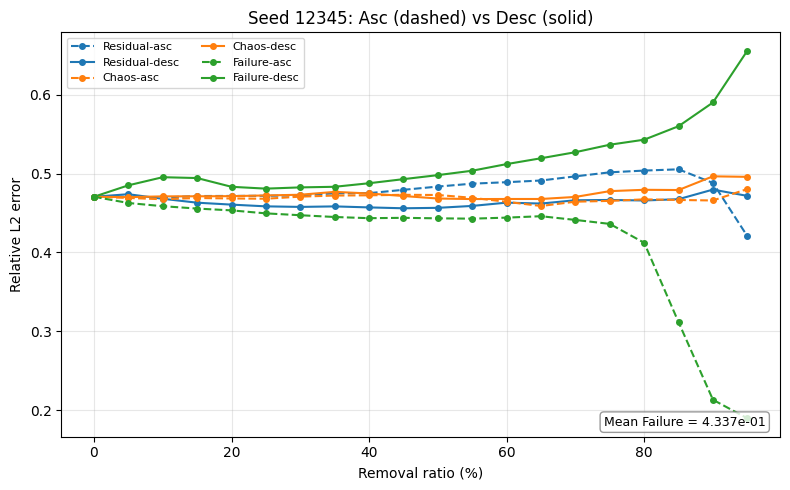

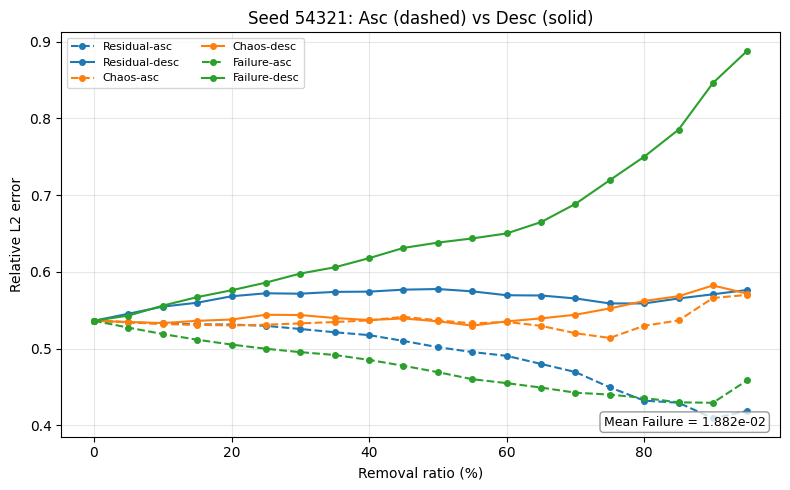

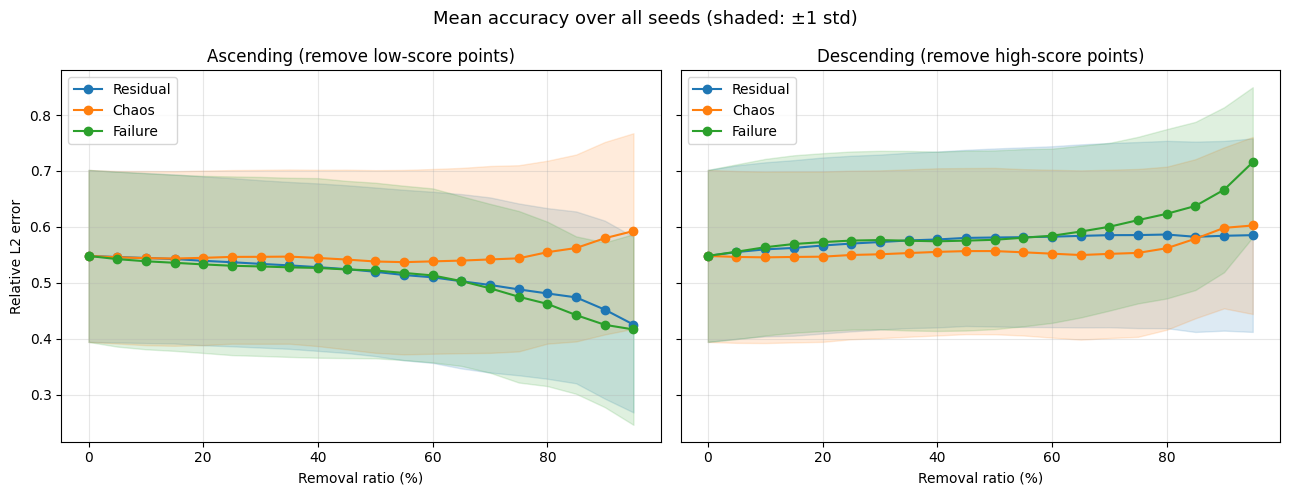

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 加载数据
# ============================================================
df = pd.read_csv('warmupdnn/dnn_biaozhun_results.csv')
print("dnn_biaozhun")

# 自动确定指标顺序和颜色
preferred = ['Residual', 'Chaos', 'Failure']
metrics_order = [m for m in preferred if m in df['metric'].unique()]
color_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
colors = {m: c for m, c in zip(metrics_order, color_list)}

print('Metrics found:', metrics_order)
print('Seeds found   :', sorted(df['seed'].unique()))
print('Orders found  :', sorted(df['order'].unique()))


# # ============================================================
# # 2. 每个种子一张图（升序 + 降序并排）
# # ============================================================
# for seed in sorted(df['seed'].unique()):
#     sub = df[df['seed'] == seed]
#     mf = sub['mean_failure'].iloc[0]

#     fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

#     for ax, order, title in zip(
#             axes,
#             ['asc', 'desc'],
#             ['Ascending (remove low-score points)',
#              'Descending (remove high-score points)']):

#         s = sub[sub['order'] == order]
#         for metric in metrics_order:
#             m = s[s['metric'] == metric].sort_values('remove_ratio')
#             ax.plot(m['remove_ratio'] * 100,
#                     m['L2'],
#                     marker='o', markersize=4,
#                     color=colors[metric],
#                     label=metric)

#         ax.set_xlabel('Removal ratio (%)')
#         ax.set_title(title)
#         ax.grid(alpha=0.3)
#         ax.legend()
#         ax.text(0.98, 0.02, f'Mean Failure = {mf:.3e}',
#                 transform=ax.transAxes,
#                 ha='right', va='bottom', fontsize=9,
#                 bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

#     axes[0].set_ylabel('Relative L2 error')
#     fig.suptitle(f'Seed {seed}: Accuracy (L2) vs Removal ratio', fontsize=13)
#     plt.tight_layout()
#     plt.show()





# ============================================================
# 4. 升序 + 降序同图（实线 / 虚线区分）
# ============================================================
for seed in sorted(df['seed'].unique()):
    sub = df[df['seed'] == seed]
    mf = sub['mean_failure'].iloc[0]

    plt.figure(figsize=(8, 5))
    for metric in metrics_order:
        for order, ls in [('asc', '--'), ('desc', '-')]:
            m = sub[(sub['metric'] == metric) &
                    (sub['order'] == order)].sort_values('remove_ratio')
            plt.plot(m['remove_ratio'] * 100,
                     m['L2'],
                     linestyle=ls, marker='o', markersize=4,
                     color=colors[metric],
                     label=f'{metric}-{order}')

    plt.xlabel('Removal ratio (%)')
    plt.ylabel('Relative L2 error')
    plt.title(f'Seed {seed}: Asc (dashed) vs Desc (solid)')
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.text(0.98, 0.02, f'Mean Failure = {mf:.3e}',
             transform=plt.gca().transAxes,
             ha='right', va='bottom', fontsize=9,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
    plt.tight_layout()
    plt.show()


# ============================================================
# 5. 所有种子平均趋势（可选，带 ±1 std 阴影）
# ============================================================
summary = (df.groupby(['order', 'metric', 'remove_ratio'])
             .agg(mean_L2=('L2', 'mean'),
                  std_L2=('L2', 'std'),
                  mean_failure=('mean_failure', 'mean'))
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, order, title in zip(axes, ['asc', 'desc'],
                            ['Ascending (remove low-score points)',
                             'Descending (remove high-score points)']):
    s = summary[summary['order'] == order]
    for metric in metrics_order:
        m = s[s['metric'] == metric].sort_values('remove_ratio')
        ax.plot(m['remove_ratio'] * 100, m['mean_L2'],
                marker='o', color=colors[metric], label=metric)
        ax.fill_between(m['remove_ratio'] * 100,
                        m['mean_L2'] - m['std_L2'],
                        m['mean_L2'] + m['std_L2'],
                        color=colors[metric], alpha=0.15)
    ax.set_xlabel('Removal ratio (%)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Relative L2 error')
fig.suptitle('Mean accuracy over all seeds (shaded: ±1 std)', fontsize=13)
plt.tight_layout()
plt.show()

dnn_residual
Metrics found: ['Residual', 'Chaos', 'Failure']
Seeds found   : [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321]
Orders found  : ['asc', 'desc']


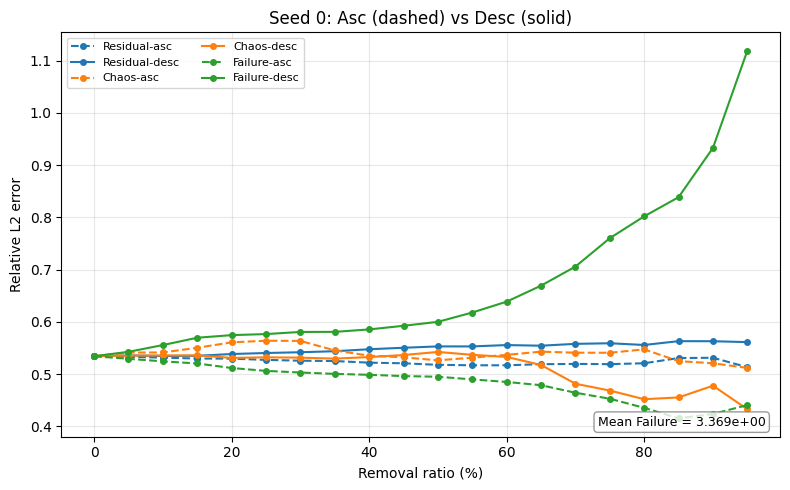

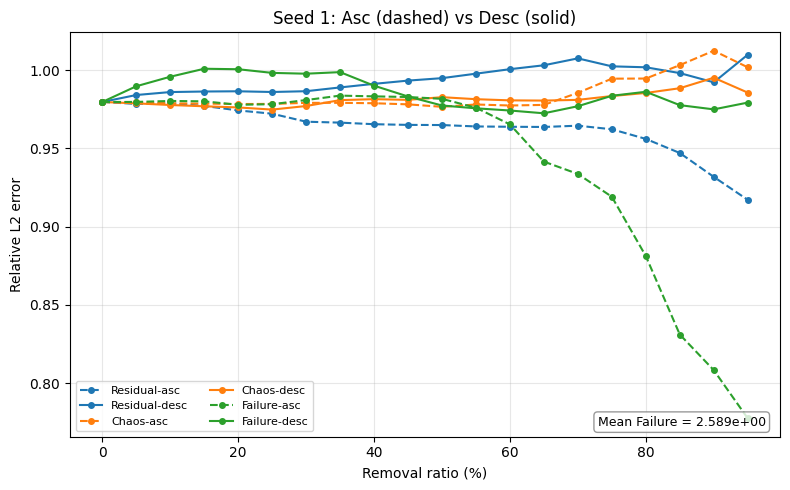

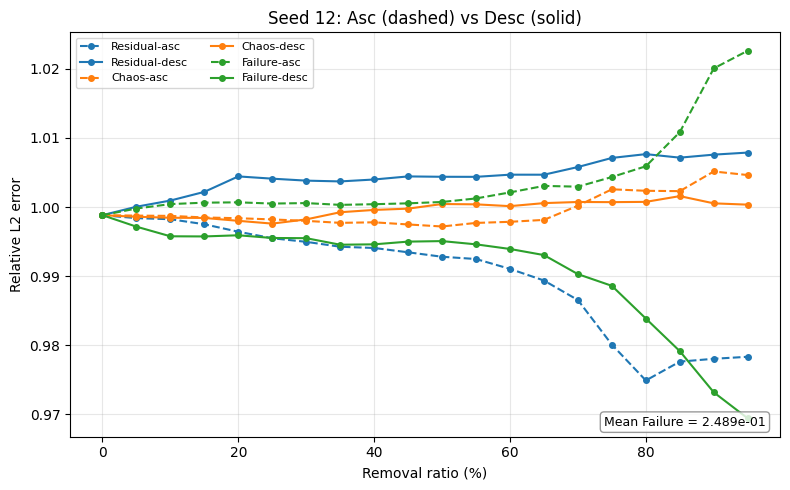

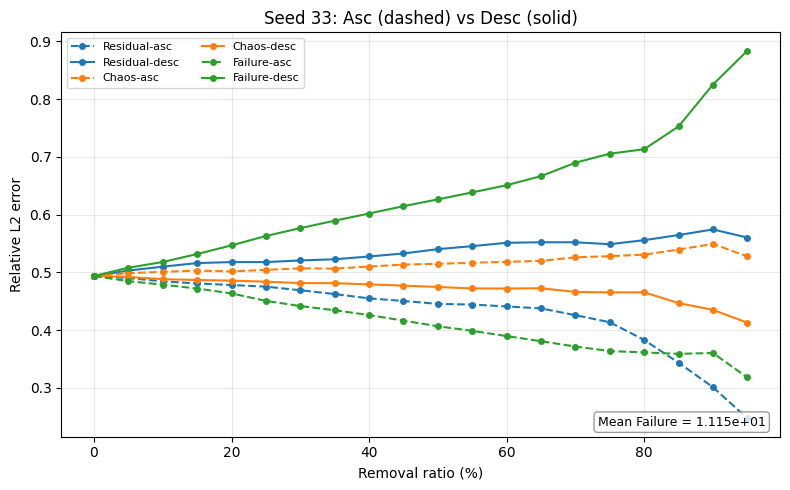

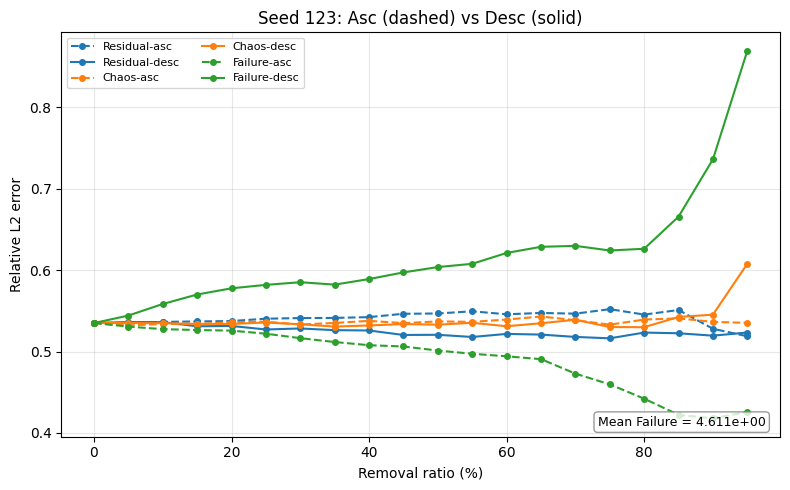

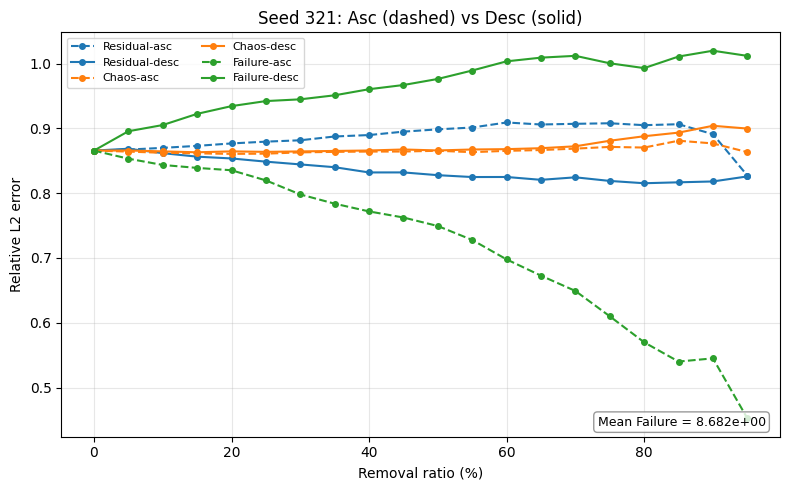

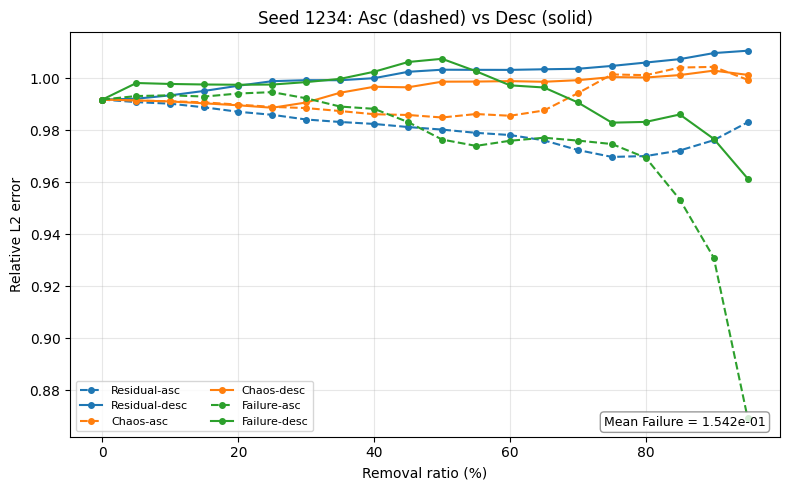

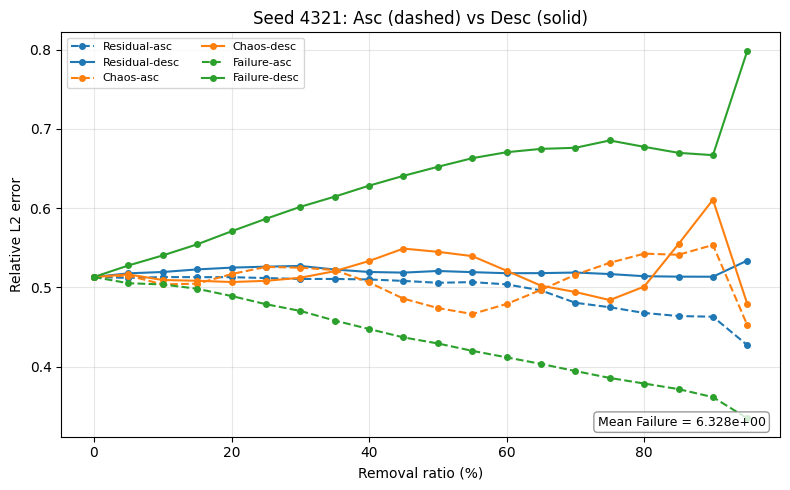

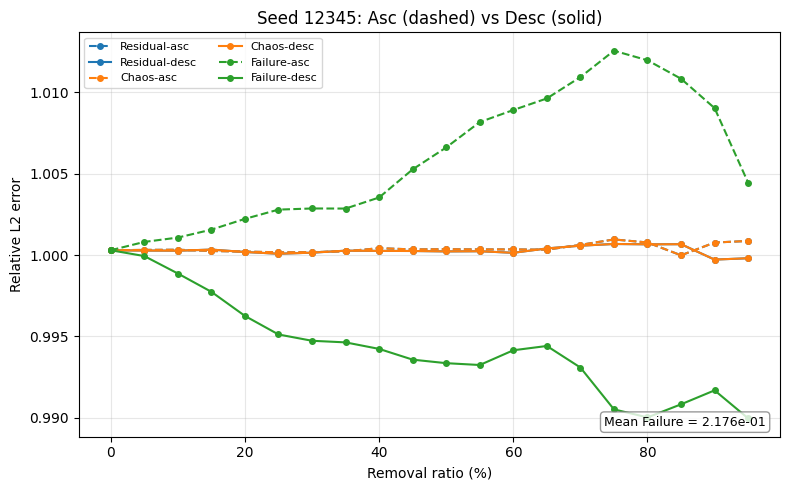

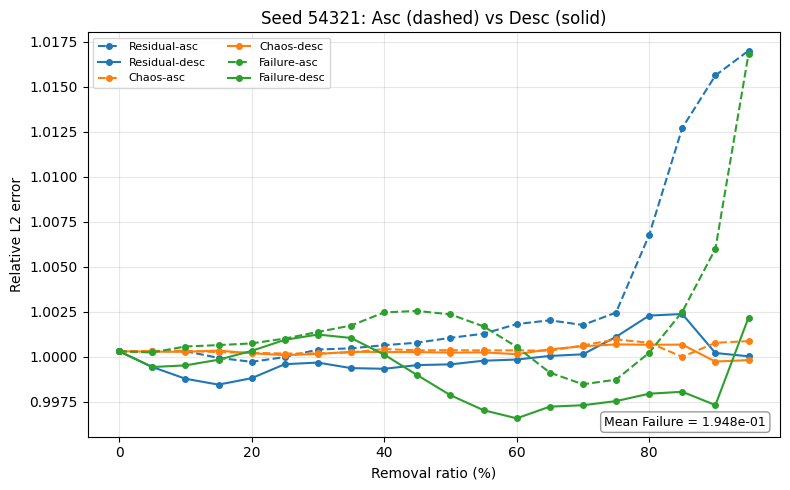

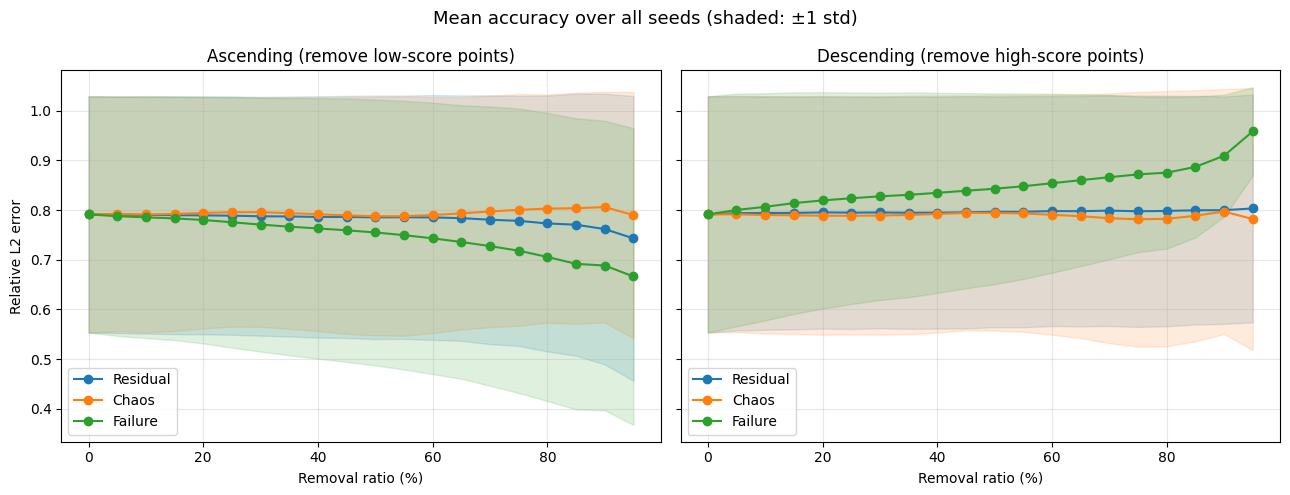

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 加载数据
# ============================================================
df = pd.read_csv('warmupdnn/dnn_residual_results.csv')
print("dnn_residual")

# 自动确定指标顺序和颜色
preferred = ['Residual', 'Chaos', 'Failure']
metrics_order = [m for m in preferred if m in df['metric'].unique()]
color_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
colors = {m: c for m, c in zip(metrics_order, color_list)}

print('Metrics found:', metrics_order)
print('Seeds found   :', sorted(df['seed'].unique()))
print('Orders found  :', sorted(df['order'].unique()))


# # ============================================================
# # 2. 每个种子一张图（升序 + 降序并排）
# # ============================================================
# for seed in sorted(df['seed'].unique()):
#     sub = df[df['seed'] == seed]
#     mf = sub['mean_failure'].iloc[0]

#     fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

#     for ax, order, title in zip(
#             axes,
#             ['asc', 'desc'],
#             ['Ascending (remove low-score points)',
#              'Descending (remove high-score points)']):

#         s = sub[sub['order'] == order]
#         for metric in metrics_order:
#             m = s[s['metric'] == metric].sort_values('remove_ratio')
#             ax.plot(m['remove_ratio'] * 100,
#                     m['L2'],
#                     marker='o', markersize=4,
#                     color=colors[metric],
#                     label=metric)

#         ax.set_xlabel('Removal ratio (%)')
#         ax.set_title(title)
#         ax.grid(alpha=0.3)
#         ax.legend()
#         ax.text(0.98, 0.02, f'Mean Failure = {mf:.3e}',
#                 transform=ax.transAxes,
#                 ha='right', va='bottom', fontsize=9,
#                 bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

#     axes[0].set_ylabel('Relative L2 error')
#     fig.suptitle(f'Seed {seed}: Accuracy (L2) vs Removal ratio', fontsize=13)
#     plt.tight_layout()
#     plt.show()





# ============================================================
# 4. 升序 + 降序同图（实线 / 虚线区分）
# ============================================================
for seed in sorted(df['seed'].unique()):
    sub = df[df['seed'] == seed]
    mf = sub['mean_failure'].iloc[0]

    plt.figure(figsize=(8, 5))
    for metric in metrics_order:
        for order, ls in [('asc', '--'), ('desc', '-')]:
            m = sub[(sub['metric'] == metric) &
                    (sub['order'] == order)].sort_values('remove_ratio')
            plt.plot(m['remove_ratio'] * 100,
                     m['L2'],
                     linestyle=ls, marker='o', markersize=4,
                     color=colors[metric],
                     label=f'{metric}-{order}')

    plt.xlabel('Removal ratio (%)')
    plt.ylabel('Relative L2 error')
    plt.title(f'Seed {seed}: Asc (dashed) vs Desc (solid)')
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.text(0.98, 0.02, f'Mean Failure = {mf:.3e}',
             transform=plt.gca().transAxes,
             ha='right', va='bottom', fontsize=9,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
    plt.tight_layout()
    plt.show()


# ============================================================
# 5. 所有种子平均趋势（可选，带 ±1 std 阴影）
# ============================================================
summary = (df.groupby(['order', 'metric', 'remove_ratio'])
             .agg(mean_L2=('L2', 'mean'),
                  std_L2=('L2', 'std'),
                  mean_failure=('mean_failure', 'mean'))
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, order, title in zip(axes, ['asc', 'desc'],
                            ['Ascending (remove low-score points)',
                             'Descending (remove high-score points)']):
    s = summary[summary['order'] == order]
    for metric in metrics_order:
        m = s[s['metric'] == metric].sort_values('remove_ratio')
        ax.plot(m['remove_ratio'] * 100, m['mean_L2'],
                marker='o', color=colors[metric], label=metric)
        ax.fill_between(m['remove_ratio'] * 100,
                        m['mean_L2'] - m['std_L2'],
                        m['mean_L2'] + m['std_L2'],
                        color=colors[metric], alpha=0.15)
    ax.set_xlabel('Removal ratio (%)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Relative L2 error')
fig.suptitle('Mean accuracy over all seeds (shaded: ±1 std)', fontsize=13)
plt.tight_layout()
plt.show()

former_biaozhun
Metrics found: ['Residual', 'Chaos', 'Failure']
Seeds found   : [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321]
Orders found  : ['asc', 'desc']


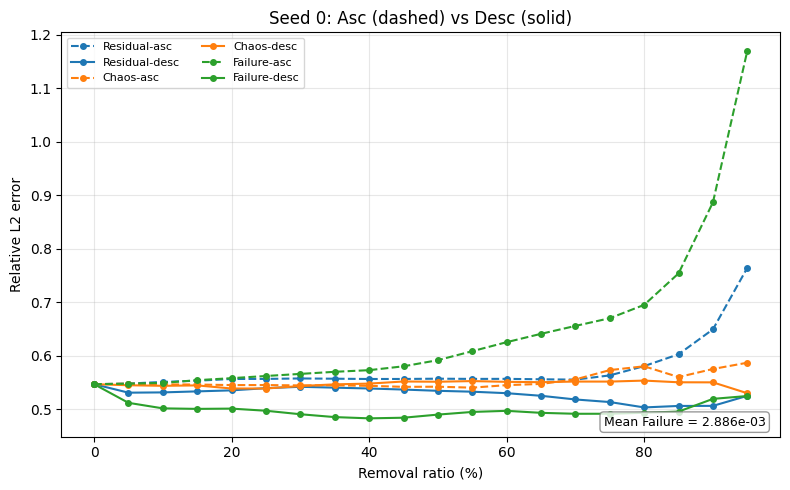

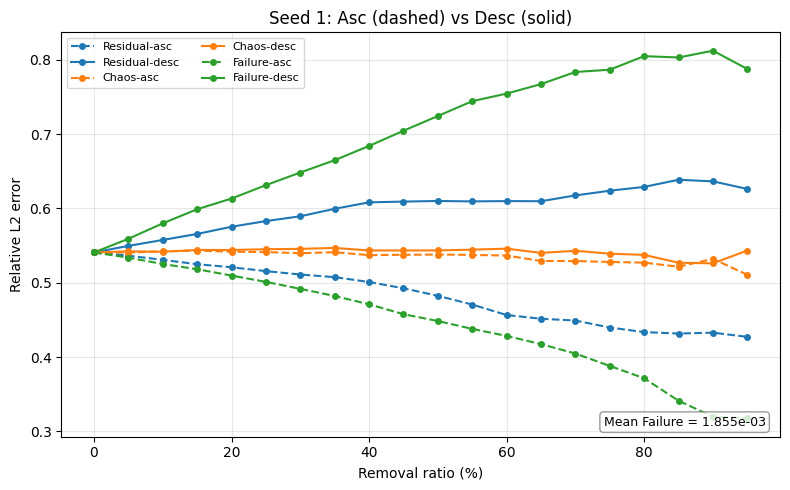

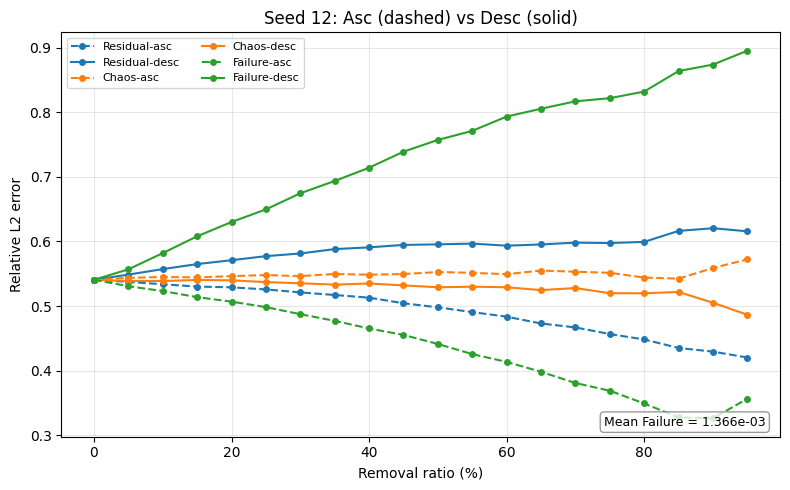

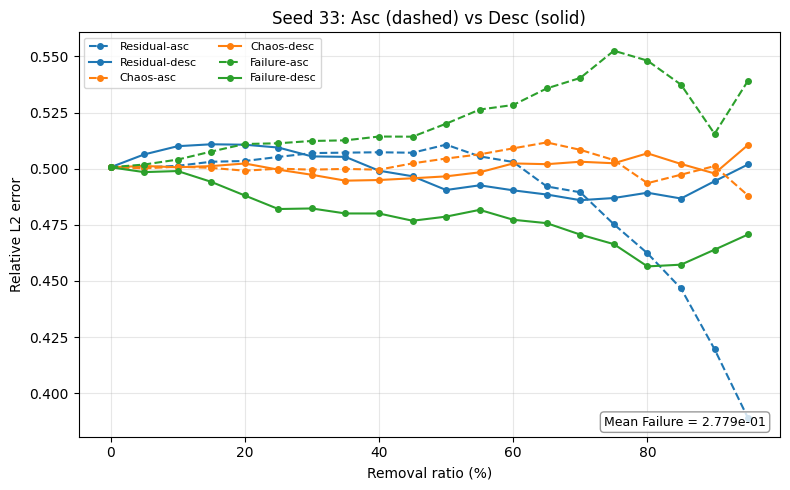

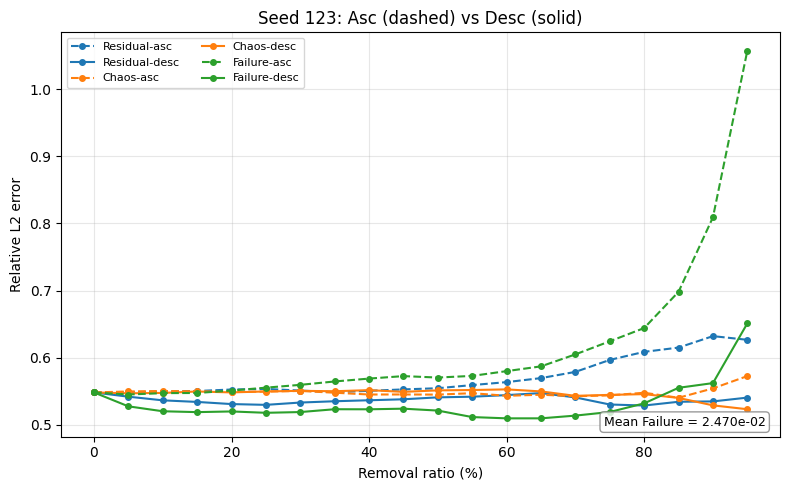

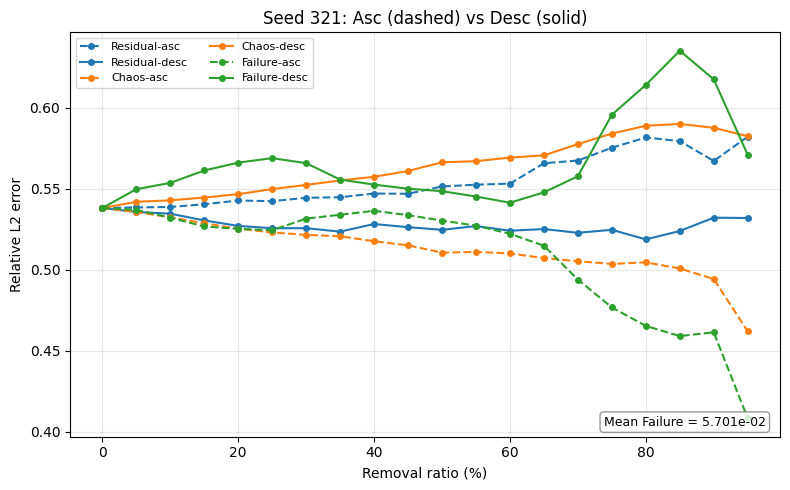

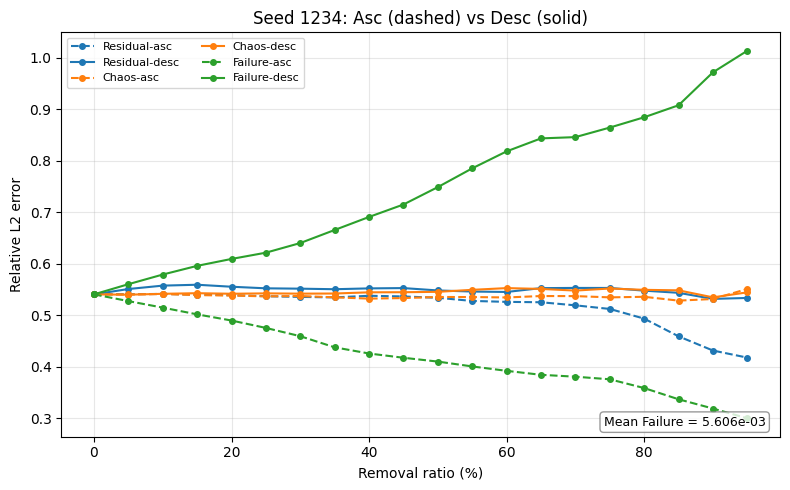

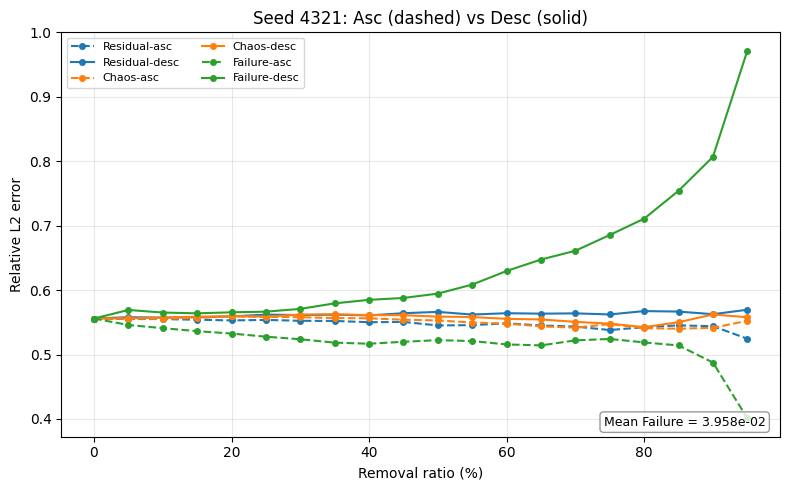

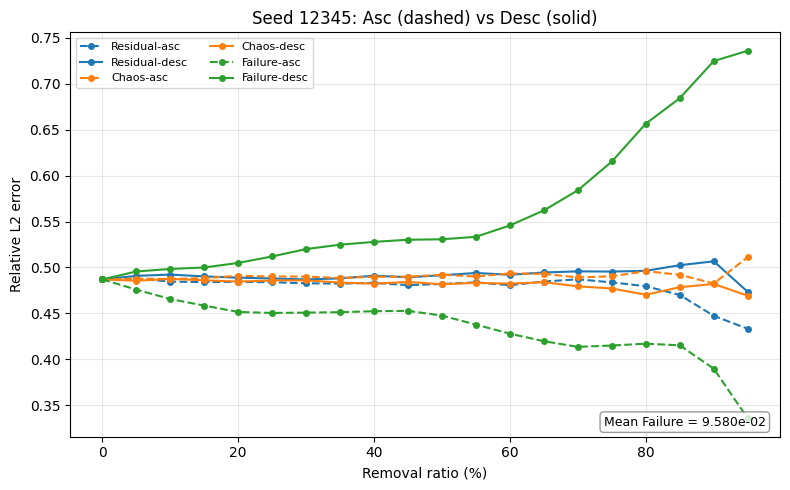

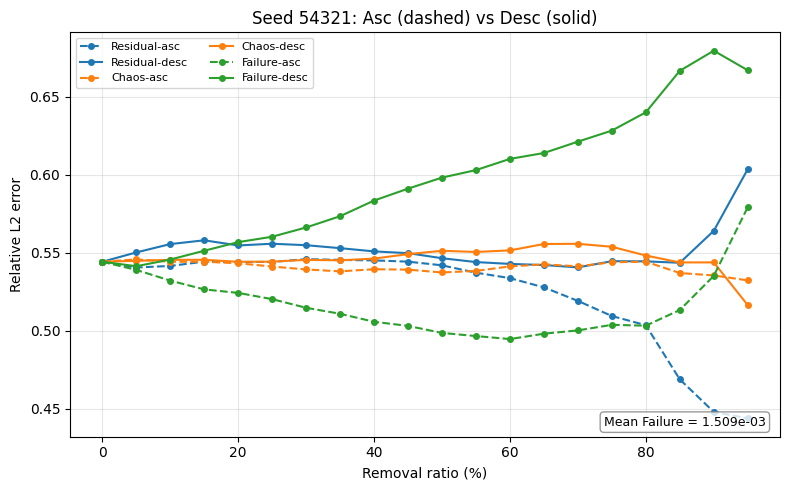

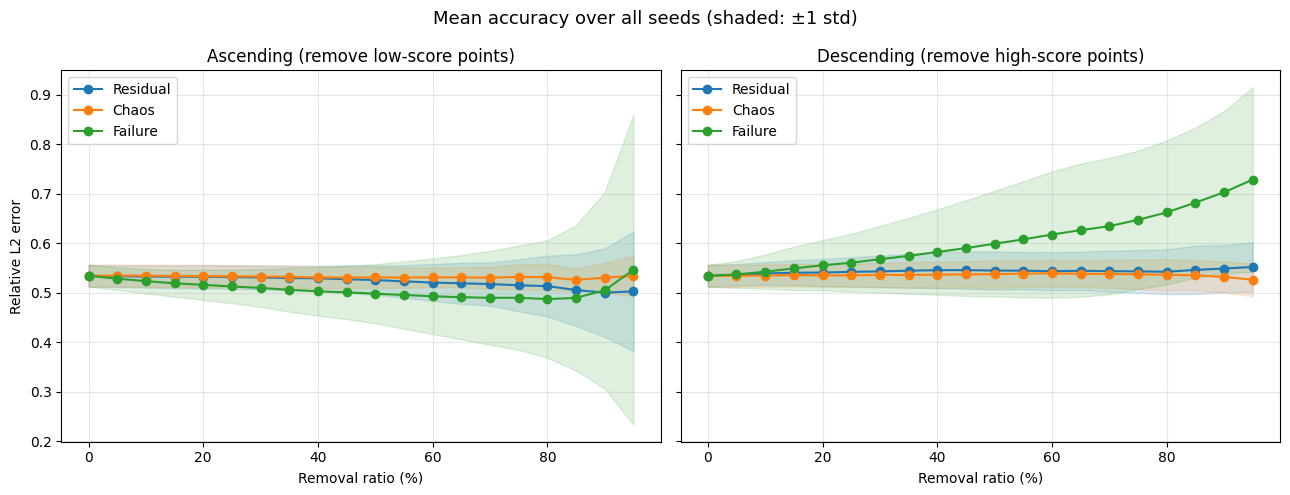

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 加载数据
# ============================================================
df = pd.read_csv('warmupformer/former_biaozhun_results.csv')
print("former_biaozhun")

# 自动确定指标顺序和颜色
preferred = ['Residual', 'Chaos', 'Failure']
metrics_order = [m for m in preferred if m in df['metric'].unique()]
color_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
colors = {m: c for m, c in zip(metrics_order, color_list)}

print('Metrics found:', metrics_order)
print('Seeds found   :', sorted(df['seed'].unique()))
print('Orders found  :', sorted(df['order'].unique()))


# # ============================================================
# # 2. 每个种子一张图（升序 + 降序并排）
# # ============================================================
# for seed in sorted(df['seed'].unique()):
#     sub = df[df['seed'] == seed]
#     mf = sub['mean_failure'].iloc[0]

#     fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

#     for ax, order, title in zip(
#             axes,
#             ['asc', 'desc'],
#             ['Ascending (remove low-score points)',
#              'Descending (remove high-score points)']):

#         s = sub[sub['order'] == order]
#         for metric in metrics_order:
#             m = s[s['metric'] == metric].sort_values('remove_ratio')
#             ax.plot(m['remove_ratio'] * 100,
#                     m['L2'],
#                     marker='o', markersize=4,
#                     color=colors[metric],
#                     label=metric)

#         ax.set_xlabel('Removal ratio (%)')
#         ax.set_title(title)
#         ax.grid(alpha=0.3)
#         ax.legend()
#         ax.text(0.98, 0.02, f'Mean Failure = {mf:.3e}',
#                 transform=ax.transAxes,
#                 ha='right', va='bottom', fontsize=9,
#                 bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

#     axes[0].set_ylabel('Relative L2 error')
#     fig.suptitle(f'Seed {seed}: Accuracy (L2) vs Removal ratio', fontsize=13)
#     plt.tight_layout()
#     plt.show()





# ============================================================
# 4. 升序 + 降序同图（实线 / 虚线区分）
# ============================================================
for seed in sorted(df['seed'].unique()):
    sub = df[df['seed'] == seed]
    mf = sub['mean_failure'].iloc[0]

    plt.figure(figsize=(8, 5))
    for metric in metrics_order:
        for order, ls in [('asc', '--'), ('desc', '-')]:
            m = sub[(sub['metric'] == metric) &
                    (sub['order'] == order)].sort_values('remove_ratio')
            plt.plot(m['remove_ratio'] * 100,
                     m['L2'],
                     linestyle=ls, marker='o', markersize=4,
                     color=colors[metric],
                     label=f'{metric}-{order}')

    plt.xlabel('Removal ratio (%)')
    plt.ylabel('Relative L2 error')
    plt.title(f'Seed {seed}: Asc (dashed) vs Desc (solid)')
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.text(0.98, 0.02, f'Mean Failure = {mf:.3e}',
             transform=plt.gca().transAxes,
             ha='right', va='bottom', fontsize=9,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
    plt.tight_layout()
    plt.show()


# ============================================================
# 5. 所有种子平均趋势（可选，带 ±1 std 阴影）
# ============================================================
summary = (df.groupby(['order', 'metric', 'remove_ratio'])
             .agg(mean_L2=('L2', 'mean'),
                  std_L2=('L2', 'std'),
                  mean_failure=('mean_failure', 'mean'))
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, order, title in zip(axes, ['asc', 'desc'],
                            ['Ascending (remove low-score points)',
                             'Descending (remove high-score points)']):
    s = summary[summary['order'] == order]
    for metric in metrics_order:
        m = s[s['metric'] == metric].sort_values('remove_ratio')
        ax.plot(m['remove_ratio'] * 100, m['mean_L2'],
                marker='o', color=colors[metric], label=metric)
        ax.fill_between(m['remove_ratio'] * 100,
                        m['mean_L2'] - m['std_L2'],
                        m['mean_L2'] + m['std_L2'],
                        color=colors[metric], alpha=0.15)
    ax.set_xlabel('Removal ratio (%)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Relative L2 error')
fig.suptitle('Mean accuracy over all seeds (shaded: ±1 std)', fontsize=13)
plt.tight_layout()
plt.show()

former_residual
Metrics found: ['Residual', 'Chaos', 'Failure']
Seeds found   : [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321]
Orders found  : ['asc', 'desc']


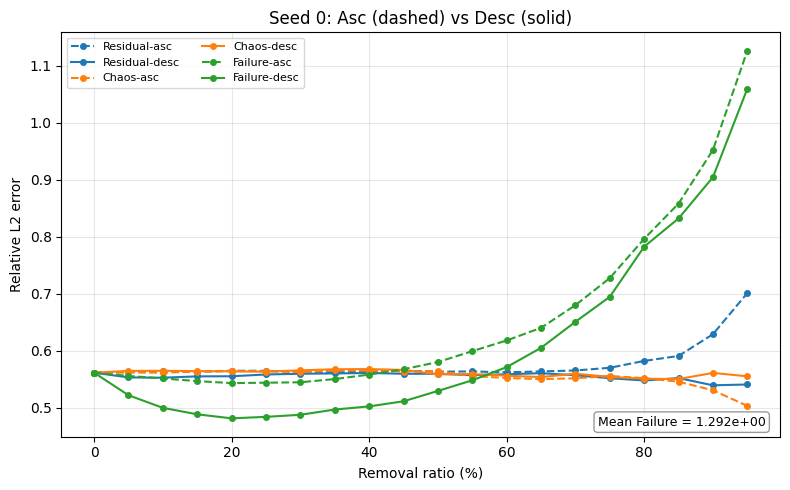

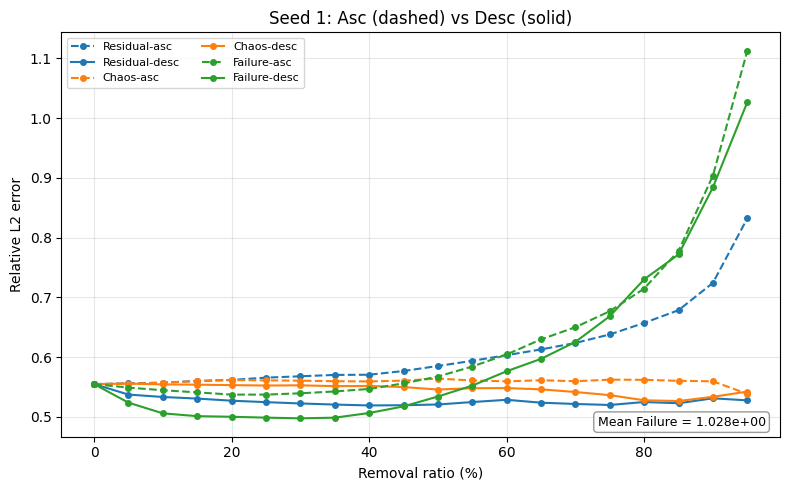

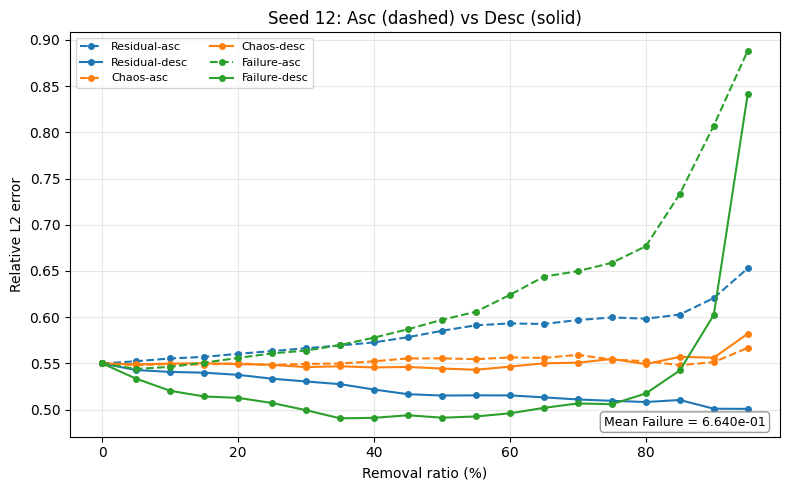

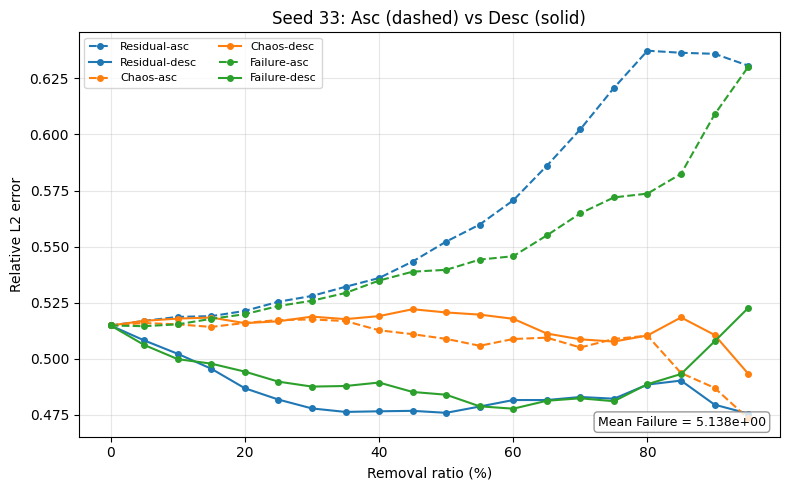

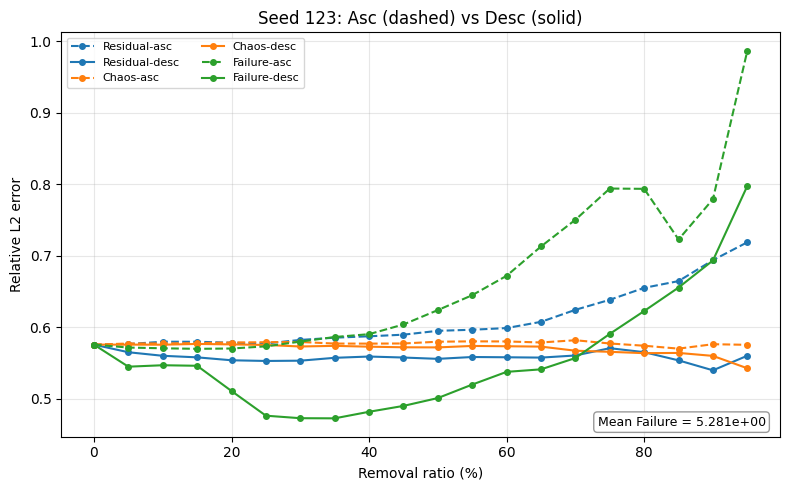

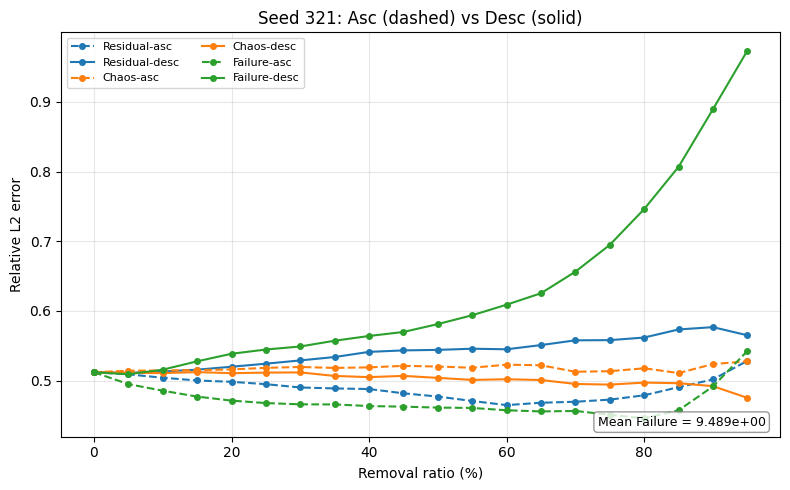

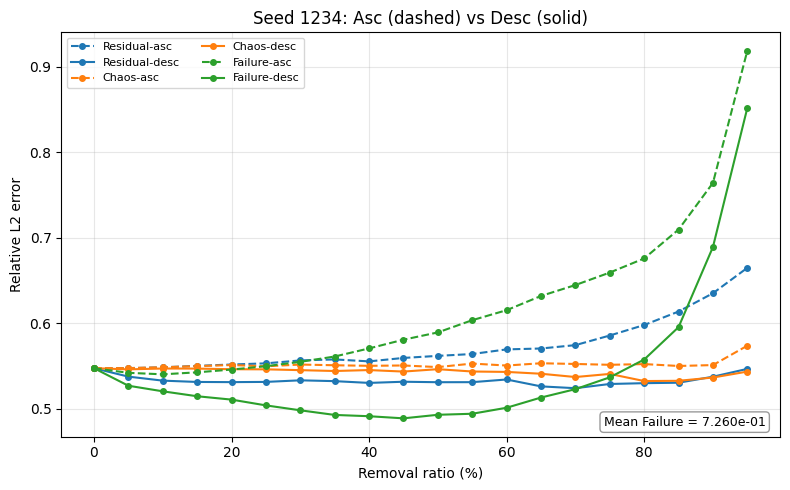

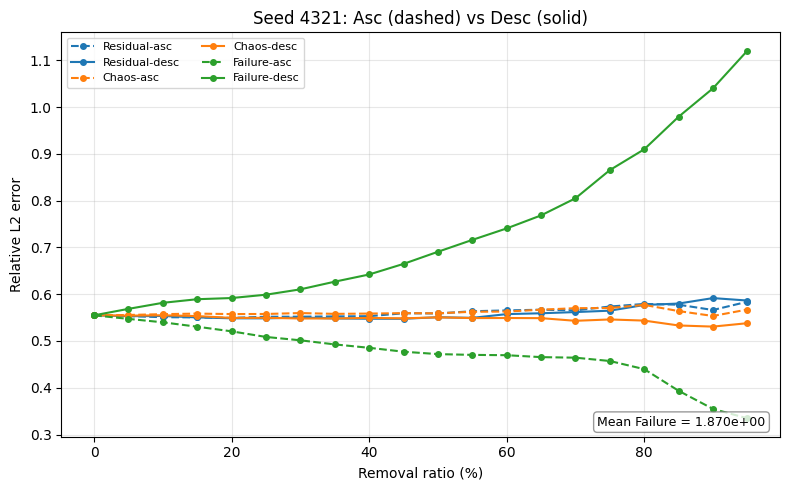

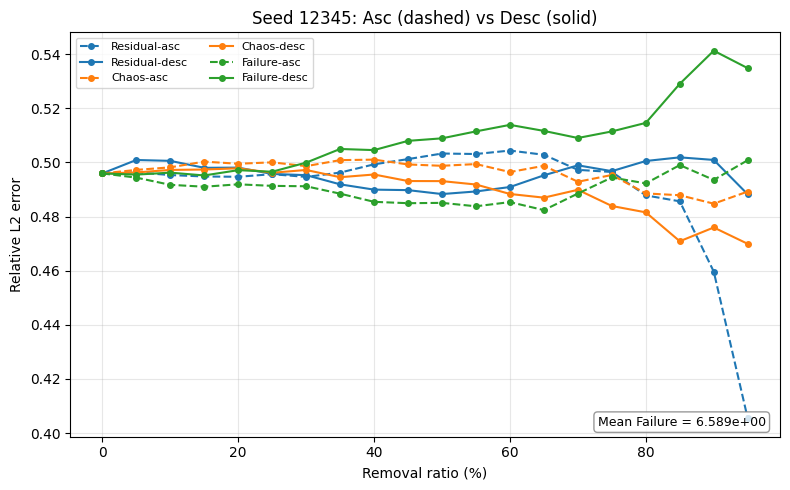

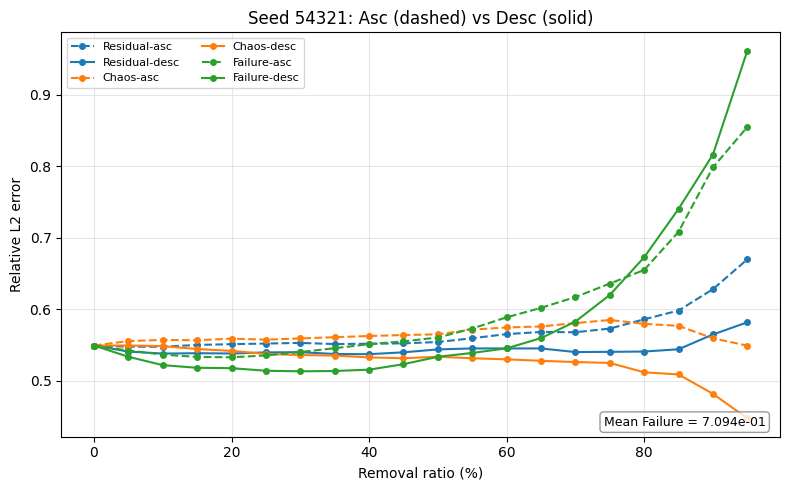

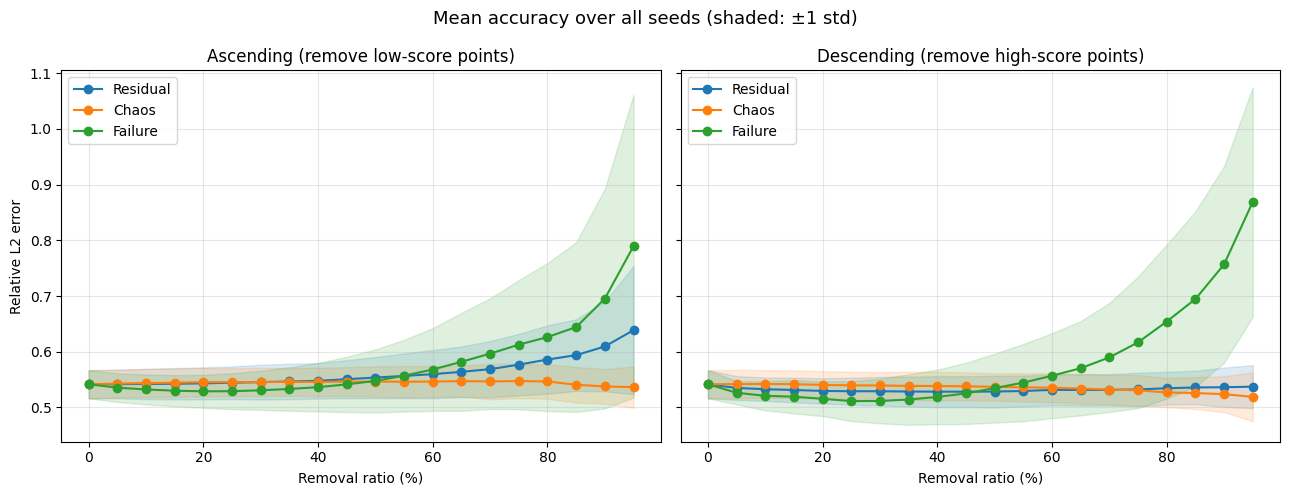

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 加载数据
# ============================================================
df = pd.read_csv('warmupformer/former_residual_results.csv')
print("former_residual")

# 自动确定指标顺序和颜色
preferred = ['Residual', 'Chaos', 'Failure']
metrics_order = [m for m in preferred if m in df['metric'].unique()]
color_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
colors = {m: c for m, c in zip(metrics_order, color_list)}

print('Metrics found:', metrics_order)
print('Seeds found   :', sorted(df['seed'].unique()))
print('Orders found  :', sorted(df['order'].unique()))


# # ============================================================
# # 2. 每个种子一张图（升序 + 降序并排）
# # ============================================================
# for seed in sorted(df['seed'].unique()):
#     sub = df[df['seed'] == seed]
#     mf = sub['mean_failure'].iloc[0]

#     fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

#     for ax, order, title in zip(
#             axes,
#             ['asc', 'desc'],
#             ['Ascending (remove low-score points)',
#              'Descending (remove high-score points)']):

#         s = sub[sub['order'] == order]
#         for metric in metrics_order:
#             m = s[s['metric'] == metric].sort_values('remove_ratio')
#             ax.plot(m['remove_ratio'] * 100,
#                     m['L2'],
#                     marker='o', markersize=4,
#                     color=colors[metric],
#                     label=metric)

#         ax.set_xlabel('Removal ratio (%)')
#         ax.set_title(title)
#         ax.grid(alpha=0.3)
#         ax.legend()
#         ax.text(0.98, 0.02, f'Mean Failure = {mf:.3e}',
#                 transform=ax.transAxes,
#                 ha='right', va='bottom', fontsize=9,
#                 bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

#     axes[0].set_ylabel('Relative L2 error')
#     fig.suptitle(f'Seed {seed}: Accuracy (L2) vs Removal ratio', fontsize=13)
#     plt.tight_layout()
#     plt.show()





# ============================================================
# 4. 升序 + 降序同图（实线 / 虚线区分）
# ============================================================
for seed in sorted(df['seed'].unique()):
    sub = df[df['seed'] == seed]
    mf = sub['mean_failure'].iloc[0]

    plt.figure(figsize=(8, 5))
    for metric in metrics_order:
        for order, ls in [('asc', '--'), ('desc', '-')]:
            m = sub[(sub['metric'] == metric) &
                    (sub['order'] == order)].sort_values('remove_ratio')
            plt.plot(m['remove_ratio'] * 100,
                     m['L2'],
                     linestyle=ls, marker='o', markersize=4,
                     color=colors[metric],
                     label=f'{metric}-{order}')

    plt.xlabel('Removal ratio (%)')
    plt.ylabel('Relative L2 error')
    plt.title(f'Seed {seed}: Asc (dashed) vs Desc (solid)')
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.text(0.98, 0.02, f'Mean Failure = {mf:.3e}',
             transform=plt.gca().transAxes,
             ha='right', va='bottom', fontsize=9,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
    plt.tight_layout()
    plt.show()


# ============================================================
# 5. 所有种子平均趋势（可选，带 ±1 std 阴影）
# ============================================================
summary = (df.groupby(['order', 'metric', 'remove_ratio'])
             .agg(mean_L2=('L2', 'mean'),
                  std_L2=('L2', 'std'),
                  mean_failure=('mean_failure', 'mean'))
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, order, title in zip(axes, ['asc', 'desc'],
                            ['Ascending (remove low-score points)',
                             'Descending (remove high-score points)']):
    s = summary[summary['order'] == order]
    for metric in metrics_order:
        m = s[s['metric'] == metric].sort_values('remove_ratio')
        ax.plot(m['remove_ratio'] * 100, m['mean_L2'],
                marker='o', color=colors[metric], label=metric)
        ax.fill_between(m['remove_ratio'] * 100,
                        m['mean_L2'] - m['std_L2'],
                        m['mean_L2'] + m['std_L2'],
                        color=colors[metric], alpha=0.15)
    ax.set_xlabel('Removal ratio (%)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Relative L2 error')
fig.suptitle('Mean accuracy over all seeds (shaded: ±1 std)', fontsize=13)
plt.tight_layout()
plt.show()

kan_biaozhun
Metrics found: ['Residual', 'Failure']
Seeds found   : [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321]
Orders found  : ['asc', 'desc']


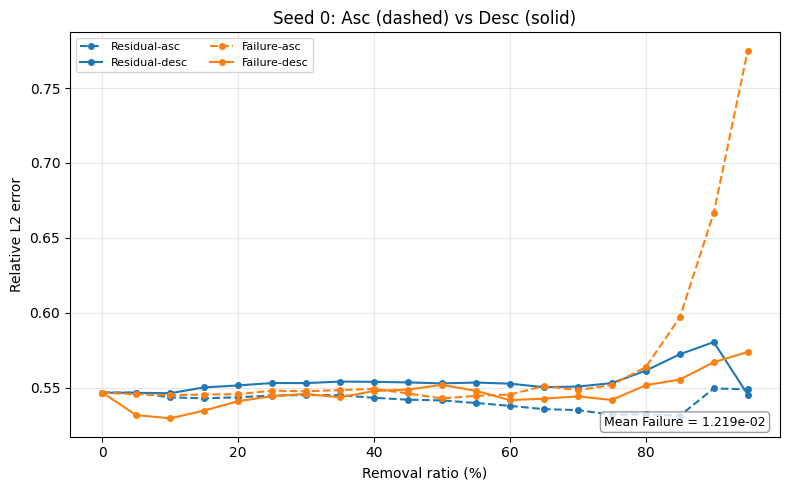

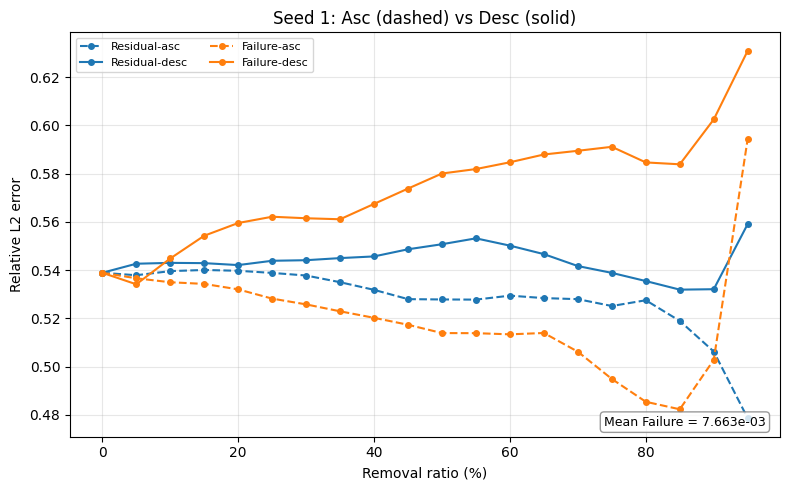

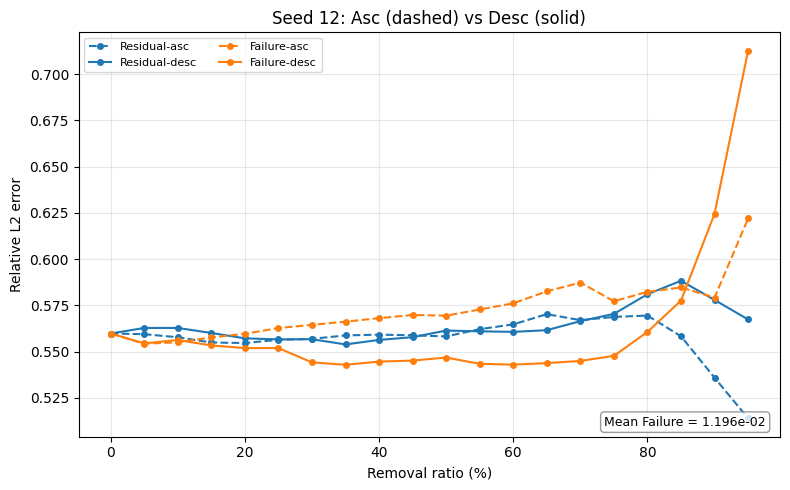

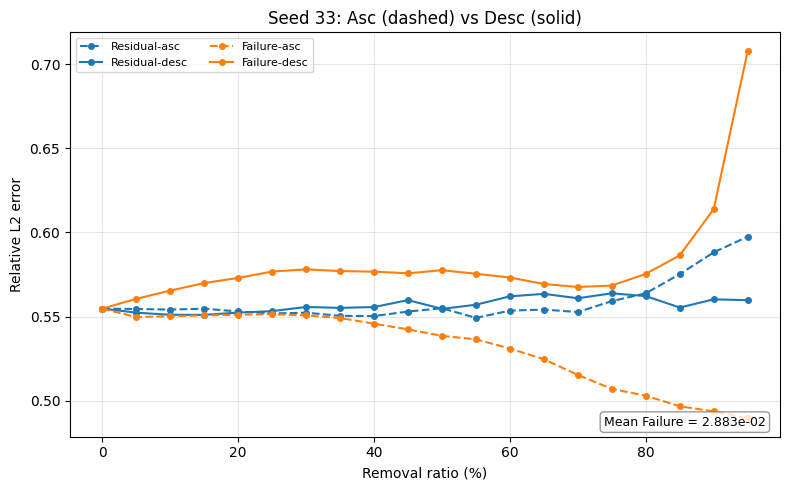

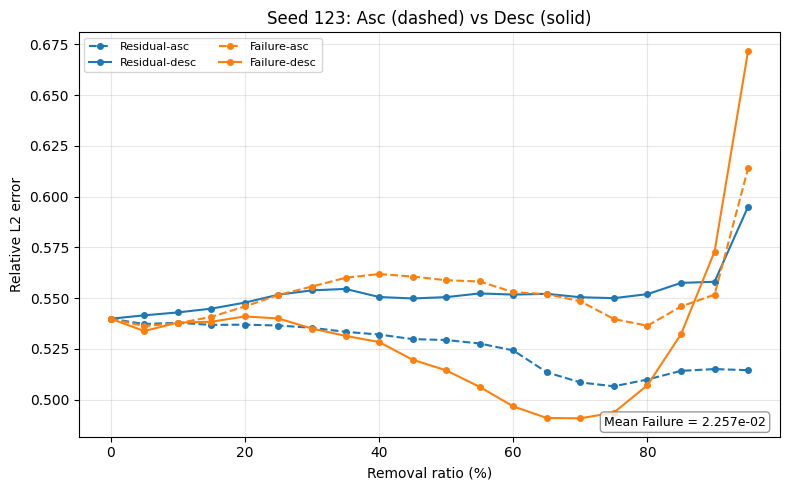

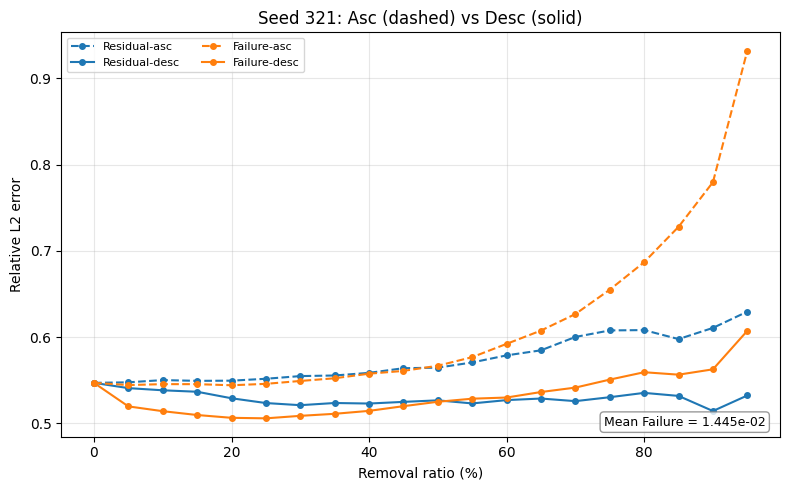

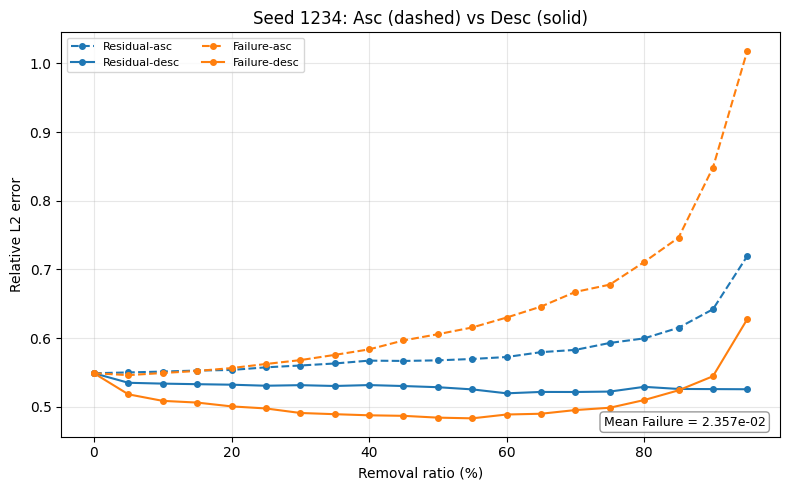

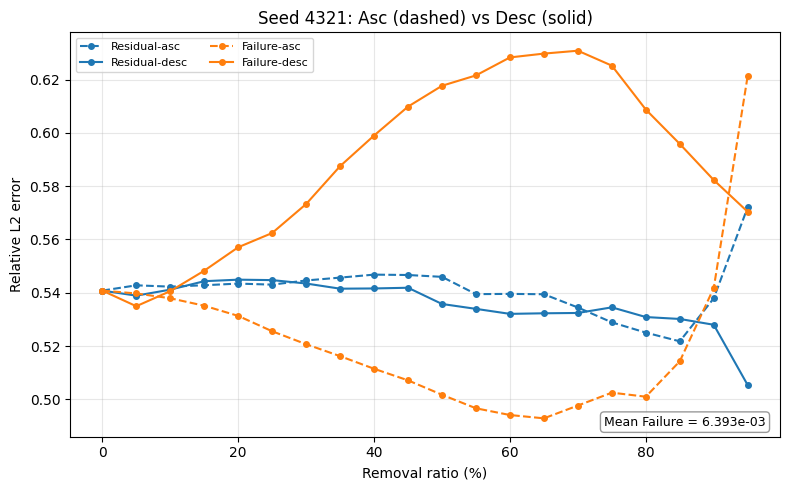

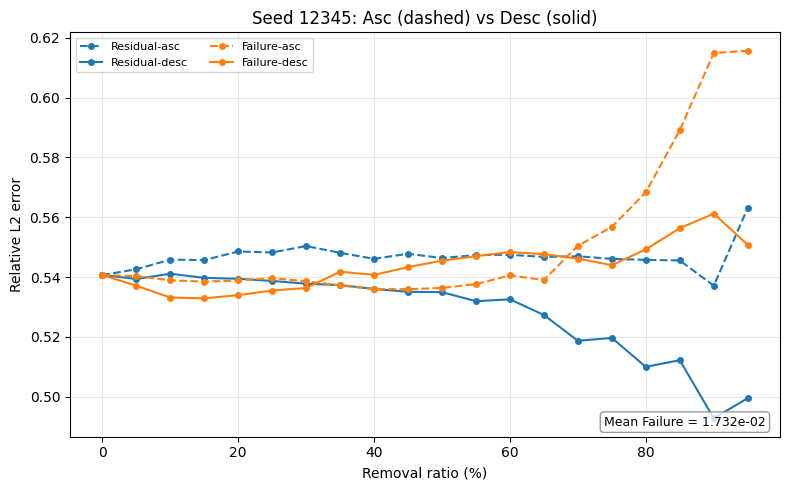

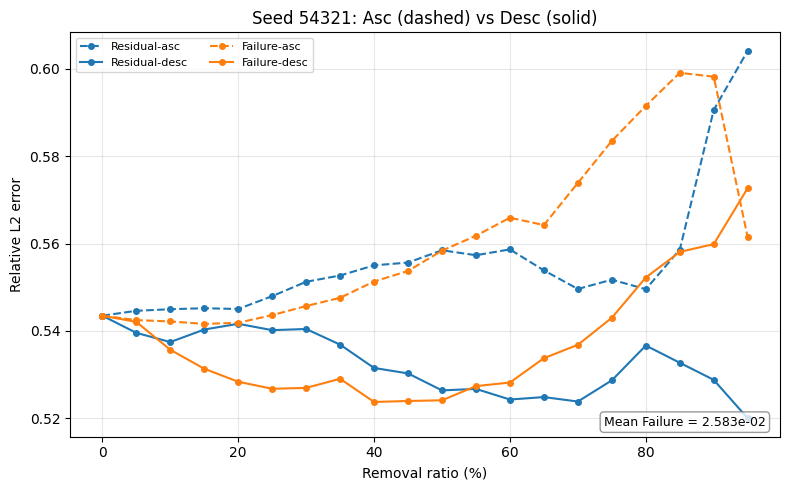

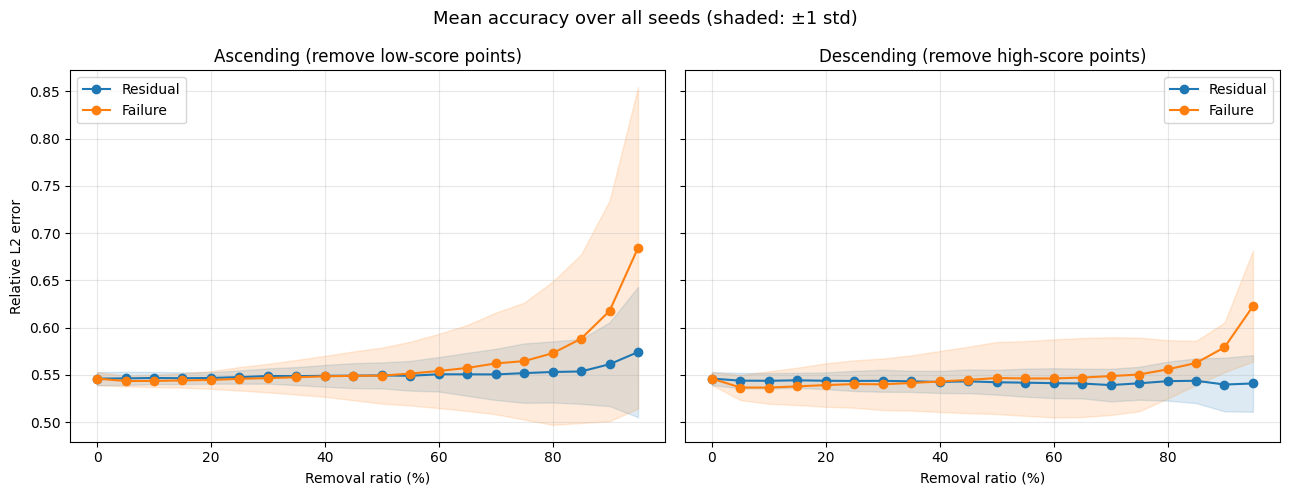

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 加载数据
# ============================================================
df = pd.read_csv('warmupKAN/kan_biaozhun_results.csv')
print("kan_biaozhun")

# 自动确定指标顺序和颜色
preferred = ['Residual', 'Chaos', 'Failure']
metrics_order = [m for m in preferred if m in df['metric'].unique()]
color_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
colors = {m: c for m, c in zip(metrics_order, color_list)}

print('Metrics found:', metrics_order)
print('Seeds found   :', sorted(df['seed'].unique()))
print('Orders found  :', sorted(df['order'].unique()))


# # ============================================================
# # 2. 每个种子一张图（升序 + 降序并排）
# # ============================================================
# for seed in sorted(df['seed'].unique()):
#     sub = df[df['seed'] == seed]
#     mf = sub['mean_failure'].iloc[0]

#     fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

#     for ax, order, title in zip(
#             axes,
#             ['asc', 'desc'],
#             ['Ascending (remove low-score points)',
#              'Descending (remove high-score points)']):

#         s = sub[sub['order'] == order]
#         for metric in metrics_order:
#             m = s[s['metric'] == metric].sort_values('remove_ratio')
#             ax.plot(m['remove_ratio'] * 100,
#                     m['L2'],
#                     marker='o', markersize=4,
#                     color=colors[metric],
#                     label=metric)

#         ax.set_xlabel('Removal ratio (%)')
#         ax.set_title(title)
#         ax.grid(alpha=0.3)
#         ax.legend()
#         ax.text(0.98, 0.02, f'Mean Failure = {mf:.3e}',
#                 transform=ax.transAxes,
#                 ha='right', va='bottom', fontsize=9,
#                 bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

#     axes[0].set_ylabel('Relative L2 error')
#     fig.suptitle(f'Seed {seed}: Accuracy (L2) vs Removal ratio', fontsize=13)
#     plt.tight_layout()
#     plt.show()





# ============================================================
# 4. 升序 + 降序同图（实线 / 虚线区分）
# ============================================================
for seed in sorted(df['seed'].unique()):
    sub = df[df['seed'] == seed]
    mf = sub['mean_failure'].iloc[0]

    plt.figure(figsize=(8, 5))
    for metric in metrics_order:
        for order, ls in [('asc', '--'), ('desc', '-')]:
            m = sub[(sub['metric'] == metric) &
                    (sub['order'] == order)].sort_values('remove_ratio')
            plt.plot(m['remove_ratio'] * 100,
                     m['L2'],
                     linestyle=ls, marker='o', markersize=4,
                     color=colors[metric],
                     label=f'{metric}-{order}')

    plt.xlabel('Removal ratio (%)')
    plt.ylabel('Relative L2 error')
    plt.title(f'Seed {seed}: Asc (dashed) vs Desc (solid)')
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.text(0.98, 0.02, f'Mean Failure = {mf:.3e}',
             transform=plt.gca().transAxes,
             ha='right', va='bottom', fontsize=9,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
    plt.tight_layout()
    plt.show()


# ============================================================
# 5. 所有种子平均趋势（可选，带 ±1 std 阴影）
# ============================================================
summary = (df.groupby(['order', 'metric', 'remove_ratio'])
             .agg(mean_L2=('L2', 'mean'),
                  std_L2=('L2', 'std'),
                  mean_failure=('mean_failure', 'mean'))
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, order, title in zip(axes, ['asc', 'desc'],
                            ['Ascending (remove low-score points)',
                             'Descending (remove high-score points)']):
    s = summary[summary['order'] == order]
    for metric in metrics_order:
        m = s[s['metric'] == metric].sort_values('remove_ratio')
        ax.plot(m['remove_ratio'] * 100, m['mean_L2'],
                marker='o', color=colors[metric], label=metric)
        ax.fill_between(m['remove_ratio'] * 100,
                        m['mean_L2'] - m['std_L2'],
                        m['mean_L2'] + m['std_L2'],
                        color=colors[metric], alpha=0.15)
    ax.set_xlabel('Removal ratio (%)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Relative L2 error')
fig.suptitle('Mean accuracy over all seeds (shaded: ±1 std)', fontsize=13)
plt.tight_layout()
plt.show()

kan_residual
Metrics found: ['Residual', 'Failure']
Seeds found   : [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321]
Orders found  : ['asc', 'desc']


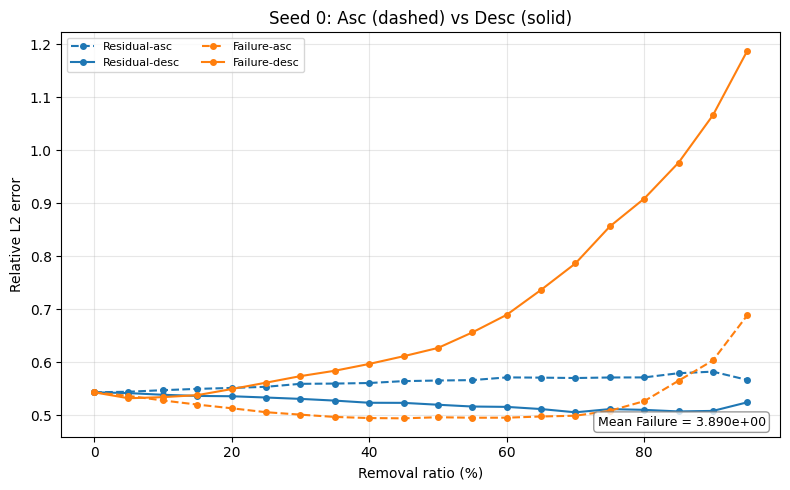

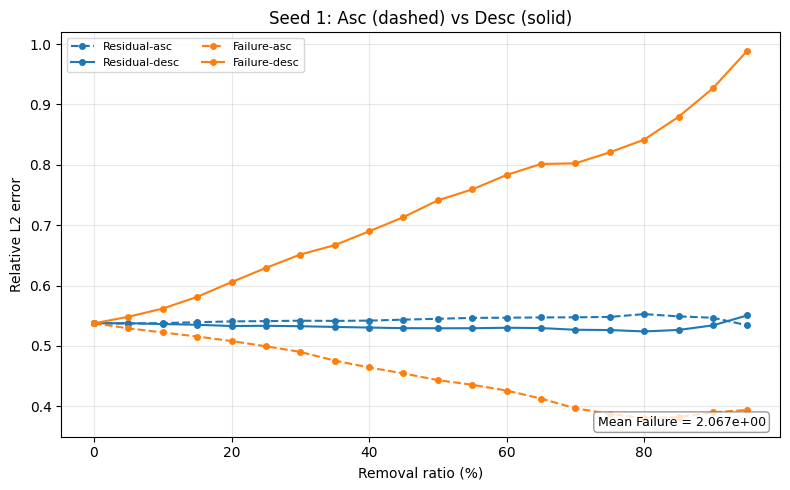

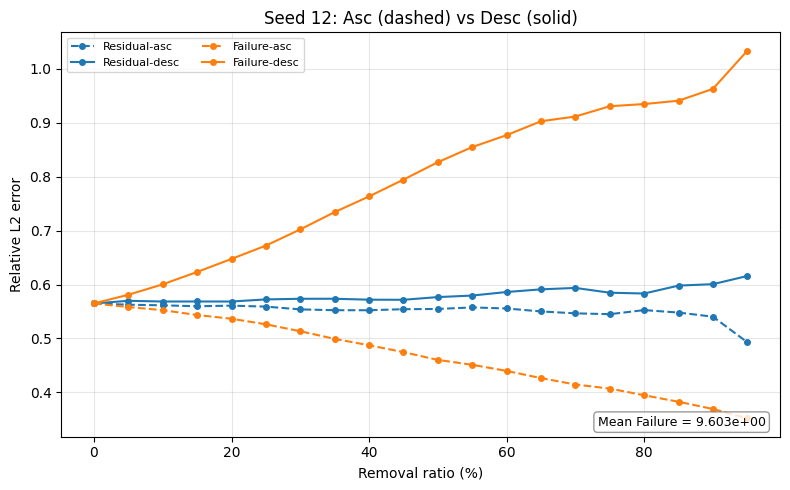

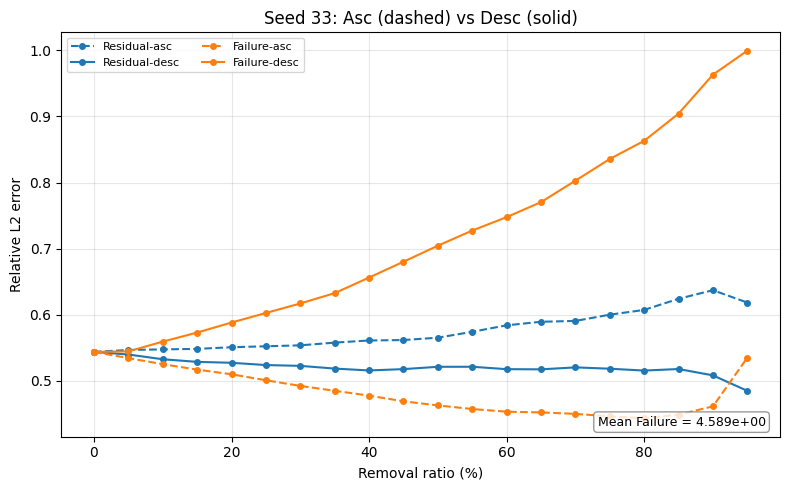

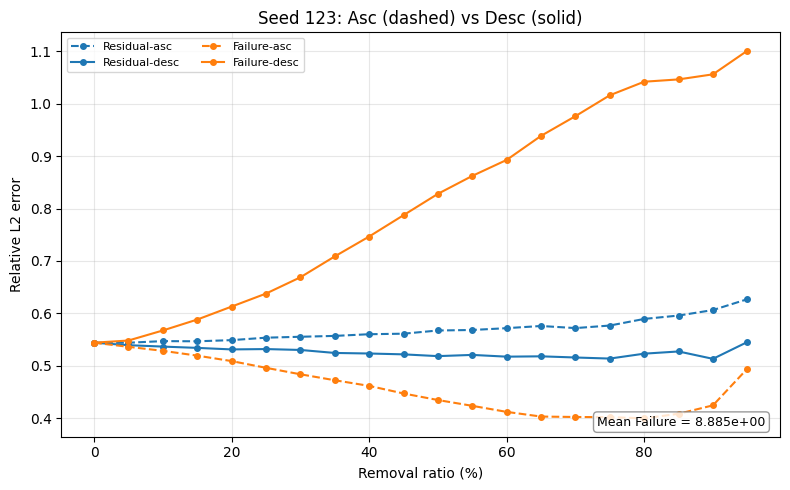

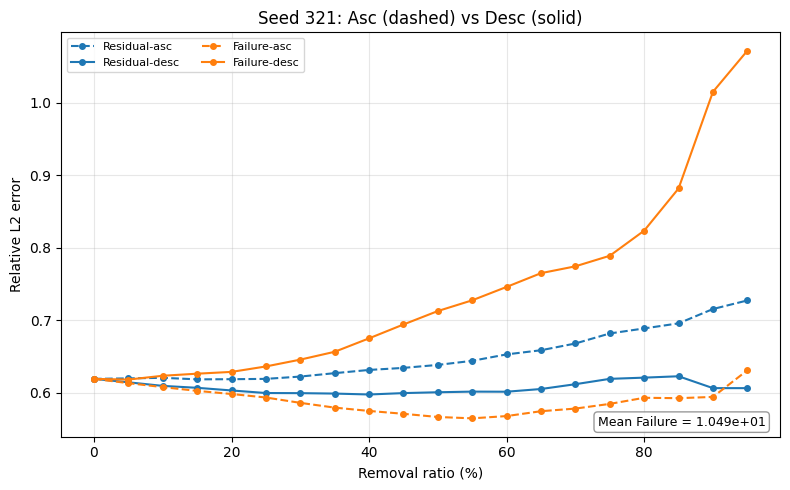

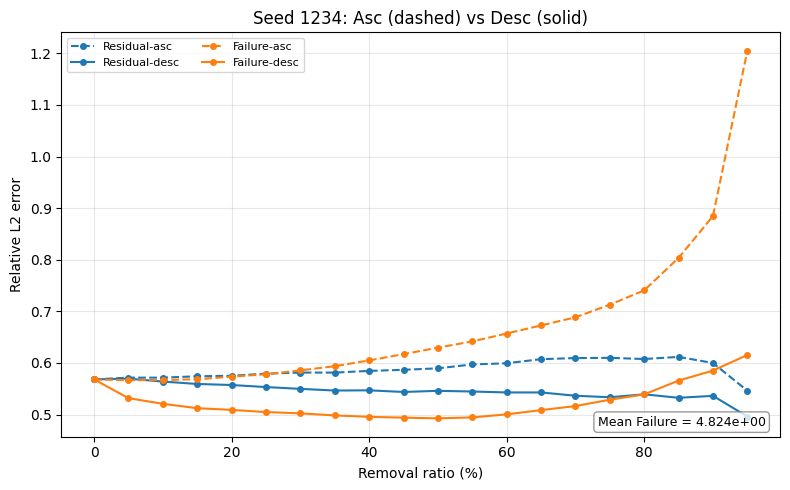

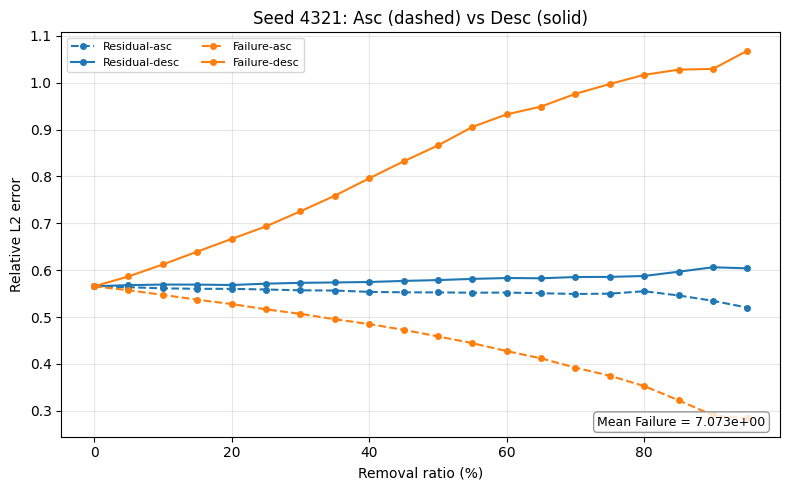

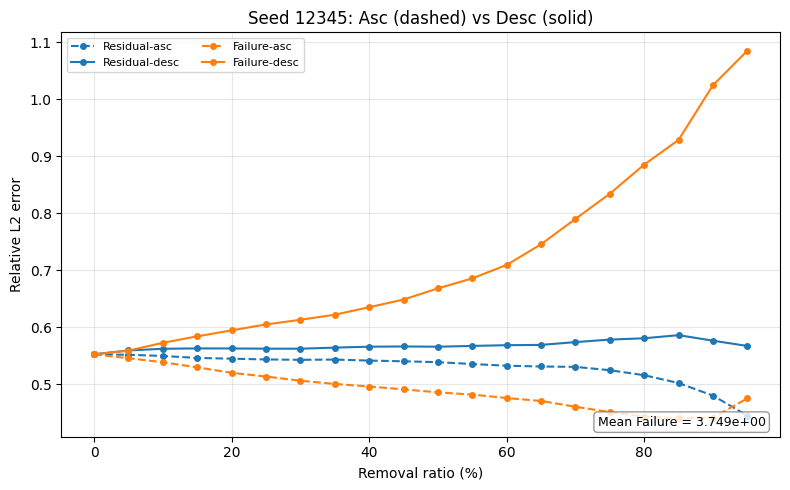

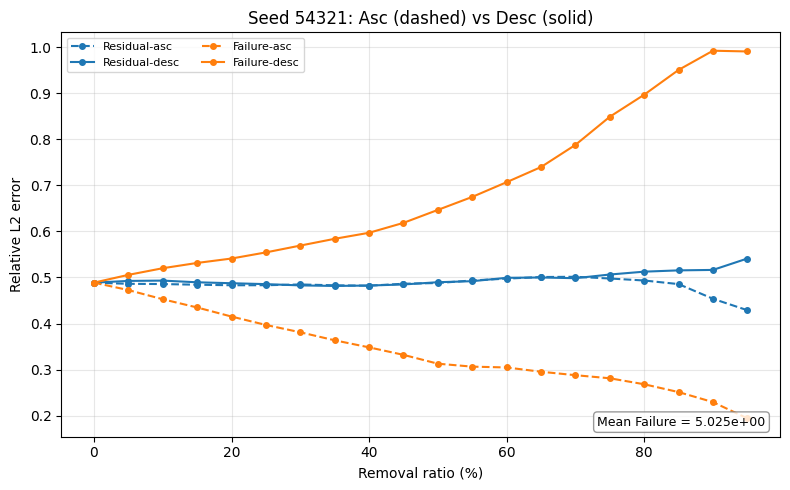

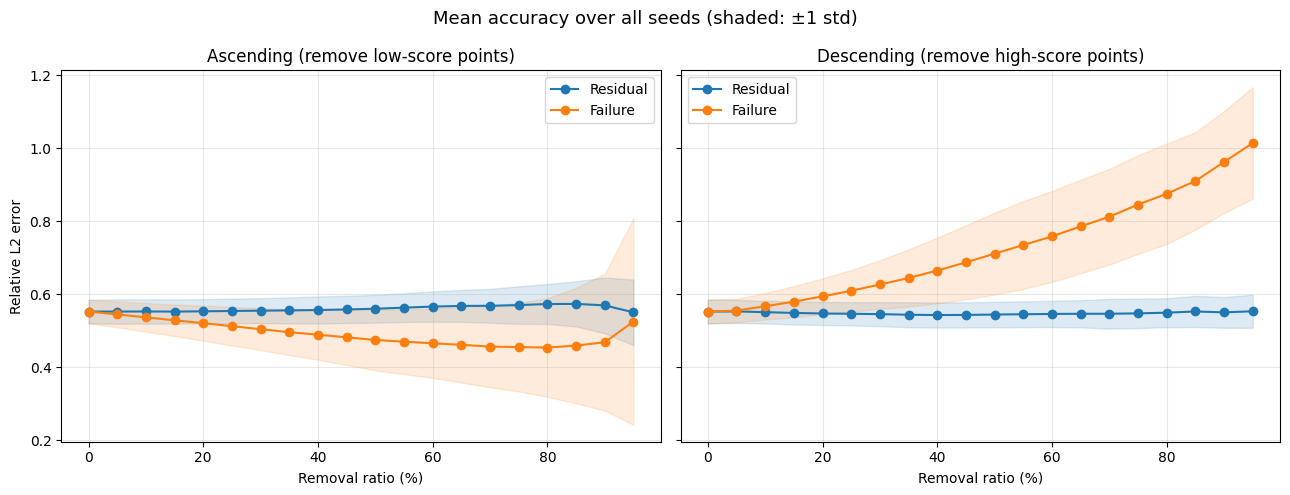

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 加载数据
# ============================================================
df = pd.read_csv('warmupKAN/kan_residual_results.csv')
print("kan_residual")

# 自动确定指标顺序和颜色
preferred = ['Residual', 'Chaos', 'Failure']
metrics_order = [m for m in preferred if m in df['metric'].unique()]
color_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
colors = {m: c for m, c in zip(metrics_order, color_list)}

print('Metrics found:', metrics_order)
print('Seeds found   :', sorted(df['seed'].unique()))
print('Orders found  :', sorted(df['order'].unique()))


# # ============================================================
# # 2. 每个种子一张图（升序 + 降序并排）
# # ============================================================
# for seed in sorted(df['seed'].unique()):
#     sub = df[df['seed'] == seed]
#     mf = sub['mean_failure'].iloc[0]

#     fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

#     for ax, order, title in zip(
#             axes,
#             ['asc', 'desc'],
#             ['Ascending (remove low-score points)',
#              'Descending (remove high-score points)']):

#         s = sub[sub['order'] == order]
#         for metric in metrics_order:
#             m = s[s['metric'] == metric].sort_values('remove_ratio')
#             ax.plot(m['remove_ratio'] * 100,
#                     m['L2'],
#                     marker='o', markersize=4,
#                     color=colors[metric],
#                     label=metric)

#         ax.set_xlabel('Removal ratio (%)')
#         ax.set_title(title)
#         ax.grid(alpha=0.3)
#         ax.legend()
#         ax.text(0.98, 0.02, f'Mean Failure = {mf:.3e}',
#                 transform=ax.transAxes,
#                 ha='right', va='bottom', fontsize=9,
#                 bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

#     axes[0].set_ylabel('Relative L2 error')
#     fig.suptitle(f'Seed {seed}: Accuracy (L2) vs Removal ratio', fontsize=13)
#     plt.tight_layout()
#     plt.show()





# ============================================================
# 4. 升序 + 降序同图（实线 / 虚线区分）
# ============================================================
for seed in sorted(df['seed'].unique()):
    sub = df[df['seed'] == seed]
    mf = sub['mean_failure'].iloc[0]

    plt.figure(figsize=(8, 5))
    for metric in metrics_order:
        for order, ls in [('asc', '--'), ('desc', '-')]:
            m = sub[(sub['metric'] == metric) &
                    (sub['order'] == order)].sort_values('remove_ratio')
            plt.plot(m['remove_ratio'] * 100,
                     m['L2'],
                     linestyle=ls, marker='o', markersize=4,
                     color=colors[metric],
                     label=f'{metric}-{order}')

    plt.xlabel('Removal ratio (%)')
    plt.ylabel('Relative L2 error')
    plt.title(f'Seed {seed}: Asc (dashed) vs Desc (solid)')
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.text(0.98, 0.02, f'Mean Failure = {mf:.3e}',
             transform=plt.gca().transAxes,
             ha='right', va='bottom', fontsize=9,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
    plt.tight_layout()
    plt.show()


# ============================================================
# 5. 所有种子平均趋势（可选，带 ±1 std 阴影）
# ============================================================
summary = (df.groupby(['order', 'metric', 'remove_ratio'])
             .agg(mean_L2=('L2', 'mean'),
                  std_L2=('L2', 'std'),
                  mean_failure=('mean_failure', 'mean'))
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, order, title in zip(axes, ['asc', 'desc'],
                            ['Ascending (remove low-score points)',
                             'Descending (remove high-score points)']):
    s = summary[summary['order'] == order]
    for metric in metrics_order:
        m = s[s['metric'] == metric].sort_values('remove_ratio')
        ax.plot(m['remove_ratio'] * 100, m['mean_L2'],
                marker='o', color=colors[metric], label=metric)
        ax.fill_between(m['remove_ratio'] * 100,
                        m['mean_L2'] - m['std_L2'],
                        m['mean_L2'] + m['std_L2'],
                        color=colors[metric], alpha=0.15)
    ax.set_xlabel('Removal ratio (%)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Relative L2 error')
fig.suptitle('Mean accuracy over all seeds (shaded: ±1 std)', fontsize=13)
plt.tight_layout()
plt.show()